In [1]:
import os
import sys
import sklearn

import pandas as pd
import numpy as np
import training_pipeline.train_maven_support as TS
import data_processing_pipeline.pipeline_support as PS
import pickle
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import spearmanr
import seaborn as sns
from matplotlib.lines import Line2D

os.getcwd()

'/Users/vivekkanpa/Documents/ISMMS/LAB_WORK/Kuan-lin_Huang_Lab/Reproducible_analysis_MAVEN'

In [2]:
print(sys.version)

3.10.16 (main, Dec 11 2024, 10:22:29) [Clang 14.0.6 ]


In [3]:
feature_colors = {
    'MAVEN_score':'#d55e00',
    'MAVEN':'#d55e00',
    'am_pathogenicity':'#029e73',
    'AlphaMissense':'#029e73',
    'ESM1b':'#ffc400',
    'CPT1_score':'#a6a6a6',
    'CPT-1':'#a6a6a6',
    'MAVEN_score_base':'#e085c2',
    'MAVEN (average)':'#e085c2',
    'norm_raw_score': '#000000',
    'MAVE score':'#000000',
    'EVE_score':'#56b4e9',
    'EVE':'#56b4e9',
    'REVEL': '#0b5394',
    'MAVEN_score+am_pathogenicity':'#d55e00',
    'MAVEN + AlphaMissense':'#d55e00',
    'EVE_score+am_pathogenicity':'#56b4e9',
    'EVE + AlphaMissense':'#56b4e9',
    'CPT1_score+am_pathogenicity':'#a6a6a6',
    'CPT-1 + AlphaMissense':'#a6a6a6',
    'ESM1b+am_pathogenicity':'#ffc400',
    'ESM1b + AlphaMissense':'#ffc400',
    'REVEL+am_pathogenicity':'#0b5394',
    'REVEL + AlphaMissense':'#0b5394',
    'MAVEN_score+am_pathogenicity':'#029e73',
    'MAVEN_score+ESM1b': '#ffc400',
    'MAVEN_score+CPT1_score' : '#a6a6a6',
    'MAVEN_score+REVEL': '#56b4e9',
    'MAVEN_score+EVE_score' : '#56b4e9',
    'MAVEN + AlphaMissense' :'#029e73',
    'MAVEN + ESM1b' : '#ffc400',
    'MAVEN + CPT-1' : '#a6a6a6',
    'MAVEN + REVEL': '#0b5394',
    'MAVEN + EVE' : '#56b4e9',
    'am_pathogenicity+MAVEN_score':'#d55e00',
    'AlphaMissense + MAVEN':'#d55e00',
    'am_pathogenicity+ESM1b':'#ffc400',
    'AlphaMissense + ESM1b':'#ffc400',
    'am_pathogenicity+CPT1_score':'#a6a6a6',
    'AlphaMissense + CPT-1':'#a6a6a6',
    'am_pathogenicity+REVEL':'#0b5394',
    'AlphaMissense + REVEL':'#0b5394',
    'am_pathogenicity+EVE_score':'#56b4e9',
    'AlphaMissense + EVE':'#56b4e9',
    }

feature_names = {
    'MAVEN_score':'MAVEN',
    'MAVEN_score_base':'MAVEN (average)',
    'MAVEN':'MAVEN',
    'norm_raw_score':'MAVE score',
    'am_pathogenicity':'AlphaMissense',
    'AlphaMissense':'AlphaMissense',
    'REVEL': 'REVEL',
    'ESM1b':'ESM1b',
    'CPT1_score':'CPT-1',
    'CPT-1':'CPT-1',
    'EVE_score':'EVE',
    'MAVEN_score+am_pathogenicity':'MAVEN + AlphaMissense', 
    'EVE_score+am_pathogenicity':'EVE + AlphaMissense',
    'CPT1_score+am_pathogenicity':'CPT-1 + AlphaMissense',
    'ESM1b+am_pathogenicity':'ESM1b + AlphaMissense',
    'REVEL+am_pathogenicity': 'REVEL + AlphaMissense',
    'MAVEN_score+am_pathogenicity':'MAVEN + AlphaMissense',
    'MAVEN_score+ESM1b': 'MAVEN + ESM1b',
    'MAVEN_score+CPT1_score' : 'MAVEN + CPT-1',
    'MAVEN_score+REVEL': 'MAVEN + REVEL',
    'MAVEN_score+EVE_score' : 'MAVEN + EVE',
    'am_pathogenicity+MAVEN_score':'AlphaMissense + MAVEN',
    'am_pathogenicity+ESM1b': 'AlphaMissense + ESM1b',
    'am_pathogenicity+CPT1_score' : 'AlphaMissense + CPT-1',
    'am_pathogenicity+REVEL': 'AlphaMissense + REVEL',
    'am_pathogenicity+EVE_score' : 'AlphaMissense + EVE'
    }


linestyle_dict = {
    'MAVEN_score':'solid',
    'MAVEN_score_base':'solid',
    'MAVEN': 'solid',
    'norm_raw_score':'solid',
    'am_pathogenicity':'solid',
    'AlphaMissense':'solid',
    'REVEL': 'solid',
    'ESM1b':'solid',
    'CPT1_score':'solid',
    'CPT-1':'solid',
    'EVE_score':'solid',
    'MAVEN_score+am_pathogenicity':'dashed',
    'EVE_score+am_pathogenicity':'dashed',
    'CPT1_score+am_pathogenicity':'dashed',
    'ESM1b+am_pathogenicity':'dashed',
    'REVEL+am_pathogenicity': 'dashed',
    'MAVEN_score+am_pathogenicity':'dashed',
    'MAVEN_score+ESM1b':'dashed',
    'MAVEN_score+CPT1_score' : 'dashed',
    'MAVEN_score+REVEL': 'dashed',
    'MAVEN_score+EVE_score' :'dashed',
    'MAVEN + AlphaMissense' :'dashed',
    'MAVEN + ESM1b' : 'dashed',
    'MAVEN + CPT-1' :'dashed',
    'MAVEN + REVEL': 'dashed',
    'MAVEN + EVE' : 'dashed',
    'am_pathogenicity+MAVEN_score':'dashed',
    'AlphaMissense + MAVEN':'dashed',
    'am_pathogenicity+ESM1b':'dashed',
    'AlphaMissense + ESM1b':'dashed',
    'am_pathogenicity+CPT1_score':'dashed',
    'AlphaMissense + CPT-1':'dashed',
    'am_pathogenicity+REVEL':'dashed',
    'AlphaMissense + REVEL':'dashed',
    'am_pathogenicity+EVE_score':'dashed',
    'AlphaMissense + EVE':'dashed', 
    }

In [4]:
# NOTE: THESE ARE MUCH FASTER TO INSTALL FROM TERMINAL (in conda venv)
# !pip install pandas==2.0.0

In [5]:
# ipykernel==6.25.2
### matplotlib==3.7.3
### numpy==1.23.5
## openpyxl==3.1.2
### optuna==3.3.0
### pandas==2.0.0
### plotly==5.16.1
### ProDy==2.4.1
### rpy2==3.5.14
### ruffus==2.8.4
### scikit-learn==1.3.0
'''
scipy==1.11.2
seaborn==0.12.2
shap==0.42.1
tqdm==4.66.1
xgboost==2.0.0
biopython==1.79
nbformat==5.9.2
xlrd==2.0.1
statsmodels==0.14.1
'''

'\nscipy==1.11.2\nseaborn==0.12.2\nshap==0.42.1\ntqdm==4.66.1\nxgboost==2.0.0\nbiopython==1.79\nnbformat==5.9.2\nxlrd==2.0.1\nstatsmodels==0.14.1\n'

In [6]:
plt.rcParams["font.family"] = "Arial"

y_percentile = 40
version = 'v1.0.0'

if not os.path.exists('maven_' + version + '/figures'+'/percentile_'+str(y_percentile)+'/benchmarks/'):
    os.mkdir('maven_' + version + '/figures'+'/percentile_'+str(y_percentile)+'/benchmarks/')
if not os.path.exists('maven_' + version + '/figures'+'/percentile_'+str(y_percentile)+'/benchmarks/external_mave/'):
    os.mkdir('maven_' + version + '/figures'+'/percentile_'+str(y_percentile)+'/benchmarks/external_mave/')

# Import training and testing datasets

In [8]:
features = PS.file_to_list('maven_' + version + '/data' +  '/percentile_'+str(y_percentile)+ '/maven_all_features_order.txt')
training_genes  = PS.file_to_list('maven_'+version+'/data/percentile_'+str(y_percentile) +'/'+'ensembl_all_training_genes.txt')
cpt1_training_genes = ['SUMO1','UBE2I','TPK1','MTHFR','CALM1']
training_genes = training_genes + cpt1_training_genes
numeric_cols = PS.file_to_list('resource_data/s8-ml-training-data/numeric_features.txt')
label_col = 'MAVE_score_binary_' + str(y_percentile) +'_percentile'

In [9]:
# Load training and holdout testing set 
X = pd.read_csv('maven_'+version+'/data/percentile_'+str(y_percentile)+'/'+'X_training_data_all.csv',low_memory=False)
X = X[X['gene'].isin(training_genes)]
X = X.set_index(['ProteinChange','gene','EnsT','aapos','aaref','aaalt','Uniprot_id','ClinicalSignificance','ClinVar Variant Category','Stars','norm_raw_score'])
X = X[features]
y = pd.read_csv('maven_'+version+'/data/percentile_'+str(y_percentile)+'/'+'y_training_data_all.csv',low_memory=False).set_index(['ProteinChange','gene','EnsT','aapos','aaref','aaalt','Uniprot_id','ClinicalSignificance','ClinVar Variant Category','Stars','norm_raw_score'])
y = y[y[label_col].isin([0,1])]
X= X.reindex(y.index)

X_test = pd.read_csv('maven_'+version+'/data/percentile_'+str(y_percentile)+'/'+'X_testing_data_all.csv',low_memory=False)
X_test = X_test.set_index(['ProteinChange','gene','EnsT','aapos','aaref','aaalt','Uniprot_id','ClinicalSignificance','ClinVar Variant Category','Stars','norm_raw_score'])
X_test = X_test[features]
y_test = pd.read_csv('maven_'+version+'/data/percentile_'+str(y_percentile)+'/'+'y_testing_data_all.csv',low_memory=False)
y_test = y_test[y_test[label_col].isin([0,1])].set_index(['ProteinChange','gene','EnsT','aapos','aaref','aaalt','Uniprot_id','ClinicalSignificance','ClinVar Variant Category','Stars','norm_raw_score'])
X_test = X_test.reindex(y_test.index)

# MAVEN predictions for testing dataset
- Make predictions with MAVEN and MAVEN (average)

In [11]:
# Load MAVEN
ensembl = pickle.load(open('maven_' + version + '/model' +  '/percentile_'+str(y_percentile)+ '/ensembl/maven_stacked_ensembl.pkl', 'rb'))

In [12]:
# Load base models of MAVEN only 
ensembl_base_genes = TS.file_to_list('maven_'+version+'/data/percentile_'+str(y_percentile) +'/'+'ensembl_base_genes.txt')
ensembl_base = []
for gene in ensembl_base_genes:
    try:
        model = pickle.load(open('maven_' + version + '/model' +  '/percentile_'+str(y_percentile)+ '/ensembl/maven_'+gene+'.pkl', 'rb'))
        ensembl_base.append(model)
    except:
        pass

In [13]:
# Function to plot AUC curve
# data = dataframe
# features = list of all features (columns in data) to calculate AUC
# ycol = column with true binary labels 0 --> bengin and 1 --> pathogenic 
# color_dict = dictionary with color assignment for each of the features 
# title = plot title 
# feature_map = dictionary to map feature column names to proper names
# annotate col = False, if True then add the # of benign and pathogenic variants used during AUC calculaton to plot 
# filename = None, will save as png file if set to a string
def plot_auc_curve(data, features, ycol, color_dict, title, feature_map, annotate_col=None,filename=None,legend_font=14):

    aucs = []
    feat = []
    for feature in features:
        if feature in list(data.columns):
            y = list(data[ycol])
            scores = list(data[feature])
            feat.append(feature)
            aucs.append(roc_auc_score(y,scores))
    df_auc = pd.DataFrame({'AUC':aucs,'Feature':feat}).sort_values(by='AUC',ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(10,8))
    for feature in df_auc['Feature']:
        if feature in data.columns:
            y = list(data[ycol])
            scores = list(data[feature])
            fpr, tpr, thr = roc_curve(y, scores, pos_label=1)
            auc = roc_auc_score(y,scores)
            linestyle='solid'
            lw=2
            if feature in color_dict.keys():
                plt.plot(fpr,tpr,label= feature_map[feature]+' (AUC='+str(round(auc,4))+')',color = color_dict[feature],lw=lw,linestyle=linestyle)
    plt.xlabel('False Positive Rate',fontsize=20)
    plt.ylabel('True Positive Rate',fontsize=20)
    plt.tick_params(axis='both', labelsize=15)
    plt.title(title,fontsize=25)
    plt.legend(loc="lower right",fontsize=legend_font)
    if annotate_col != None:
        counts = Counter(data[annotate_col])
        annotx = 0.7
        annoty = 0.7
        plt.annotate('Testing samples:',(annotx,annoty),fontsize=20)
        for key in sorted(counts.keys()):
            annoty = annoty-0.05
            plt.annotate(str(counts[key]) + ' ' + str(key),(annotx,annoty),fontsize=20 )
    if filename != None:
        plt.savefig(filename,dpi=300,bbox_inches='tight')
        plt.savefig(filename.replace('.png','.svg'),bbox_inches='tight')
    plt.show()

In [14]:
base_models =[]
for gene in training_genes:
    try:
        model = pickle.load(open('maven_' + version + '/model' +  '/percentile_'+str(y_percentile)+ '/ensembl/maven_'+gene+'.pkl', 'rb'))
        base_models.append((gene,model))
    except:
        pass

In [15]:
# Make predictions with MAVEN on both testing and training set
pred_prob_test = [x[1] for x in ensembl.predict_proba(X_test)]  
pred_prob_train =  [x[1] for x in ensembl.predict_proba(X)]

test_df = pd.DataFrame({'MAVEN':pred_prob_test})
test_df['Label'] = list(y_test[label_col])
test_df['gene'] = X_test.index.get_level_values('gene')
test_df = test_df[~test_df['Label'].isnull()].reset_index(drop=True)

train_df = pd.DataFrame({'MAVEN':pred_prob_train})
train_df['Label'] = list(y[label_col])
train_df['gene'] = X.index.get_level_values('gene')

# MAVEN performanace on MAVE-guided labels in training and testing set

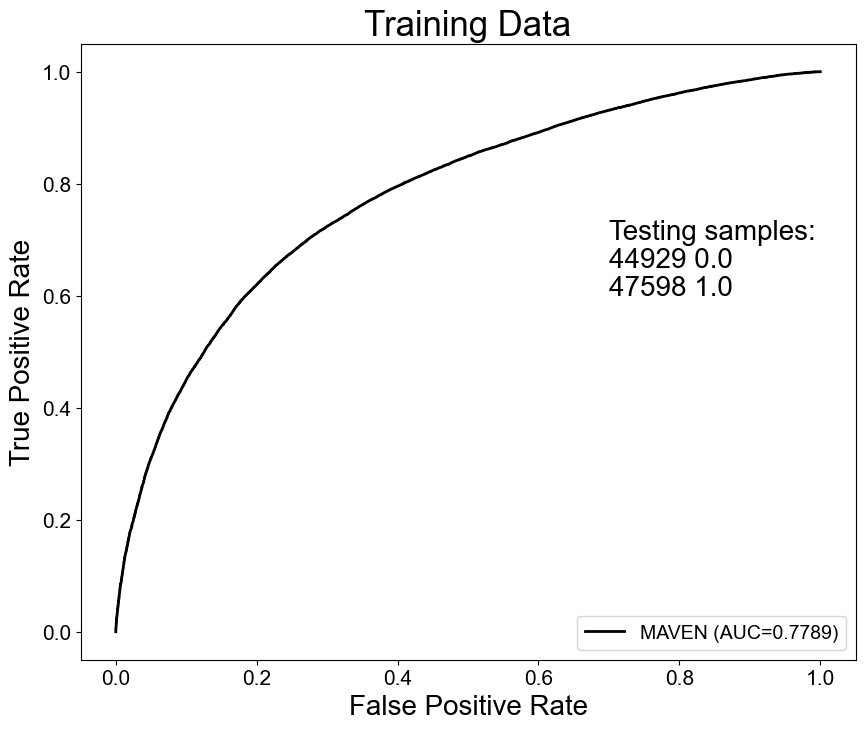

In [17]:
plot_auc_curve(train_df, ['MAVEN'], 'Label', color_dict={'MAVEN':'black'}, title='Training Data', feature_map={'MAVEN':'MAVEN'}, annotate_col='Label',filename=None,legend_font=14)

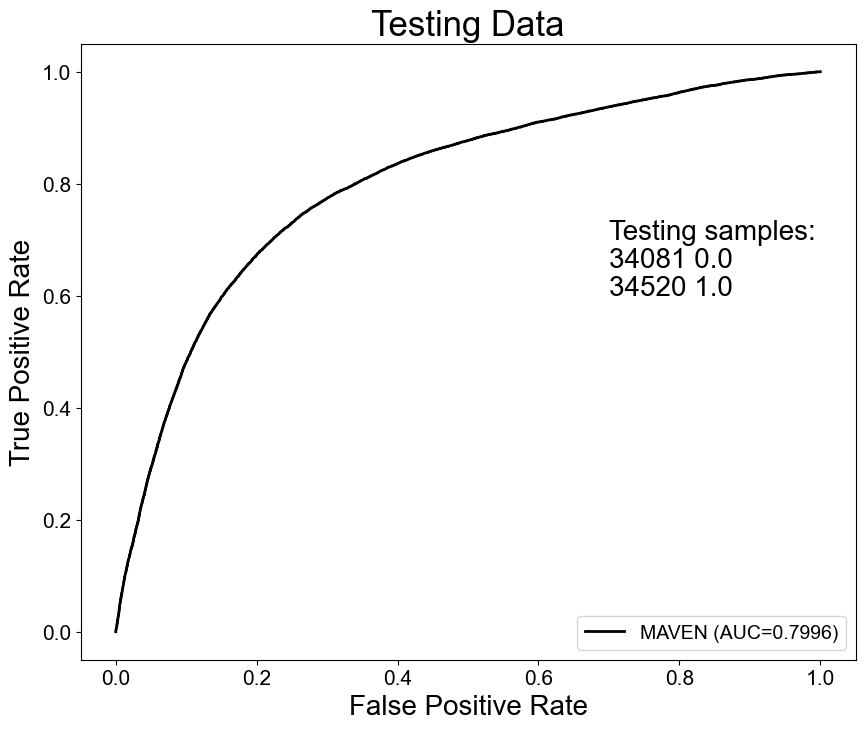

In [18]:
plot_auc_curve(test_df, ['MAVEN'], 'Label', color_dict={'MAVEN':'black'}, title='Testing Data', feature_map={'MAVEN':'MAVEN'}, annotate_col='Label',filename=None,legend_font=14)

# Retrieve scores from other VEPs for testing set

In [20]:
# Get other pathogenciity prediction scores
benchmark_dataset = pd.read_csv('resource_data/s5-features/mave_performance_benchmark_dataset_scores.csv',sep=',',index_col=0,dtype={'OpenCRAVAT_uid': str,'PrimateAI_id':str, 'UniProt Variant Category':str})
benchmark_dataset = benchmark_dataset[benchmark_dataset['Variant Type'] == 'missense']
benchmark_dataset = benchmark_dataset[~benchmark_dataset['gene'].isin(training_genes)].reset_index(drop=True)
benchmark_dataset = benchmark_dataset[benchmark_dataset['aaalt']!='*'].reset_index(drop=True)
benchmark_dataset = benchmark_dataset[(benchmark_dataset['aaalt'])!=(benchmark_dataset['aaref'])].reset_index(drop=True)
benchmark_dataset = benchmark_dataset[['gene', 'ProteinChange', 'Uniprot_id', 'ClinicalSignificance', 'ClinVar Variant Category', 'Stars',
                                       'norm_raw_score', 'EVE_score', 'ESM1b', 'am_pathogenicity', 'CPT1_score', 'REVEL']]
benchmark_dataset['ProteinChange'] = [x.split(':')[-1] for x in benchmark_dataset['ProteinChange']]
benchmark_dataset['norm_raw_score'] = [x*-1 for x in benchmark_dataset['norm_raw_score']]
benchmark_dataset = benchmark_dataset.drop_duplicates().reset_index(drop=True)

benchmark_uniprot_ids =  np.unique(benchmark_dataset['Uniprot_id'])
cols = [ 'EnsT', 'Uniprot_id', 'ProteinChange', 'aapos', 'aaref','aaalt','MAVEN_(average)_score', 'MAVEN_score', 'ClinicalSignificance','ClinVar Variant Category', 'NumberSubmitters', 'ReviewStatus', 'Stars', 'am_pathogenicity', 'am_class', 'am_class_binary', 'ESM1b', 'EVE_score', 'CPT1_score'] #'gene'
cols_2 = ['EnsT', 'Uniprot_id', 'ProteinChange', 'aapos', 'aaref', 'aaalt', 'MAVEN_(average)_score', 'MAVEN_score', 'am_pathogenicity', 'am_class', 'am_class_binary', 'ESM1b', 'EVE_score', 'CPT1_score']
full_data = pd.DataFrame(columns=cols)
missing_ind = 0
for uniprot_id in benchmark_uniprot_ids:
    try:
        maven = pd.read_csv('resource_data/s12-proteome-wide-predictions-maven-benchmarking/'+uniprot_id+'_maven.tsv.gz',sep='\t',compression='gzip',index_col=0,low_memory=False)
        maven['aapos'] = [int(x) for x in maven['aapos']]
        full_data = pd.concat([full_data,maven],ignore_index=True)
    except:
        print('missing ' + uniprot_id)
        missing_ind += 1
full_data = full_data.drop_duplicates().reset_index(drop=True)
full_data['ProteinChange'] = [x.split(':')[-1] for x in full_data['ProteinChange']]

# P01137_maven.tsv.gz
benchmark_dataset = benchmark_dataset.merge(full_data, how='left', on=['ProteinChange','Uniprot_id'])

####

for i in dict(benchmark_dataset.isna().sum()/benchmark_dataset.shape[0]):
    if dict(benchmark_dataset.isna().sum()/benchmark_dataset.shape[0])[i] == 1:
        benchmark_dataset = benchmark_dataset.drop(i, axis=1)

new_col_names = []
for h in benchmark_dataset.columns:
    if '_x' in h:
        new_col_names.append(h.split('_x')[0])
    else:
        new_col_names.append(h)

benchmark_dataset.columns = new_col_names

####


benchmark_dataset['ESM1b'] = [x*-1 for x in benchmark_dataset['ESM1b']] # reverse ESM1b score 
benchmark_dataset = benchmark_dataset[~benchmark_dataset['aaalt'].isna()].reset_index(drop=True)

missing O75400
missing P01116-2
missing P02724
missing P08631


In [21]:
benchmark_dataset.shape

(80742, 18)

In [22]:
# Get features 
external = pd.read_csv('resource_data/s8-ml-training-data/maven_X_data.csv',index_col=0, low_memory=False)
external['ProteinChange'] = [x.split(':')[-1] for x in external['ProteinChange']]
external['norm_raw_score'] = [x*-1 for x in external['norm_raw_score']]
external =  external.set_index(['ProteinChange','EnsT','aapos','aaref','aaalt','Uniprot_id','ClinicalSignificance','ClinVar Variant Category','Stars','norm_raw_score']) 

benchmark_dataset = benchmark_dataset.set_index(['ProteinChange','EnsT','aapos','aaref','aaalt','Uniprot_id','ClinicalSignificance','ClinVar Variant Category','Stars','norm_raw_score']) 

idx_overlap = benchmark_dataset.index.intersection(external.index)
benchmark_dataset = benchmark_dataset.loc[idx_overlap]
external = external.loc[idx_overlap]

external = external.reset_index()
benchmark_dataset['gene'] = list(external['gene'])
external = external.set_index(['ProteinChange','gene','EnsT','aapos','aaref','aaalt','Uniprot_id','ClinicalSignificance','ClinVar Variant Category','Stars','norm_raw_score'])[features]

benchmark_dataset = benchmark_dataset.reset_index().set_index(['ProteinChange','gene','EnsT','aapos','aaref','aaalt','Uniprot_id','ClinicalSignificance','ClinVar Variant Category','Stars','norm_raw_score'])

external_pred = [x[1] for x in ensembl.predict_proba(external)] # MAVEN
external_pred_base = PS.predict_ensembl(ensembl_base,external)  # MAVEN (average)
benchmark_dataset['MAVEN_score'] = external_pred
benchmark_dataset['MAVEN_score_base'] = external_pred_base
benchmark_dataset = benchmark_dataset.reset_index()

# Calculate correlations between VEP scores and MAVE scores in testing dataset

In [24]:
def plot_score_corr(DATA,SCORE,COMPARISONS,MAPPING=None, SCORE_TITLE = None,figsize=(35,5)):
    
    gene_col = []
    method_col = []
    corr_col = []
    best_col = []
    count_col = []

    for gene in np.unique(list(DATA['gene'])):

        
        p = DATA[DATA['gene']==gene].reset_index(drop=True)
        p = p[p['norm_raw_score']<5].reset_index(drop=True)
        color_dict = {np.nan:'NA','LP/P':'LP/P','LB/B':'LB/B'}
        p['ClinVar Variant Category'] = p['ClinVar Variant Category'].map(color_dict)
        palette={'NA':'grey','LP/P':'red','LB/B':'blue'}
        fig,ax = plt.subplots(1,len(COMPARISONS), figsize=figsize)
        params = {'mathtext.default': 'regular' }          
        plt.rcParams.update(params)

        gene_r = []
        for i,method in enumerate(COMPARISONS):

            p_method = p[~p[method].isnull()].reset_index(drop=True)
            if len(p_method) < 10: # If less than 10 datapoints in dataset, do not calcualte correlation
                p_method = pd.DataFrame(columns=DATA.columns)
            xmax = np.max(p_method[SCORE])
            ymax = np.max(p_method[method]) + (np.max(p_method[method])-np.min(p_method[method]))*0.1
            ymin = np.min(p_method[method]) - (np.max(p_method[method])-np.min(p_method[method]))*0.1
            if pd.isnull(ymax):
                ymax=1
            if pd.isnull(ymin):
                ymin=0
            
            xy = (xmax-0.5*xmax,np.min(p_method[method]))

            g = sns.scatterplot(data=p_method, x=SCORE, y=method,s=2,ax=ax[i])
    
            r = np.round(spearmanr(p_method[SCORE],p_method[method],nan_policy='omit').statistic,3)
            count_col.append(p_method.shape[0])
            ax[i].annotate(r'$\rho$='+str(r), xy, xytext=xy,fontsize=15)
            ax[i].set_ylim([ymin,ymax])
            ax[i].tick_params('both',labelsize=12)
            ax[i].set_ylabel(MAPPING[method],fontsize=15)
            if SCORE_TITLE == None:
                ax[i].set_xlabel(SCORE,fontsize=15)
            else:
                ax[i].set_xlabel(SCORE_TITLE,fontsize=15)
            ax[i].set_title(gene,fontsize=15)
            gene_col.append(gene)
            method_col.append(method)
            corr_col.append(r)
            gene_r.append(r)

        best = np.nanmax(gene_r)
        for r in gene_r:
            if r ==best:
                best_col.append('Best')
            else:
                best_col.append('NA')
            
        plt.show()


    DF = pd.DataFrame({'Gene':gene_col,'Method':method_col,'Spearman Correlation Coefficient':corr_col,'Best Performance':best_col, 'Variant Count': count_col})
   

    return(DF)

In [25]:
len(set(benchmark_dataset.gene))

50

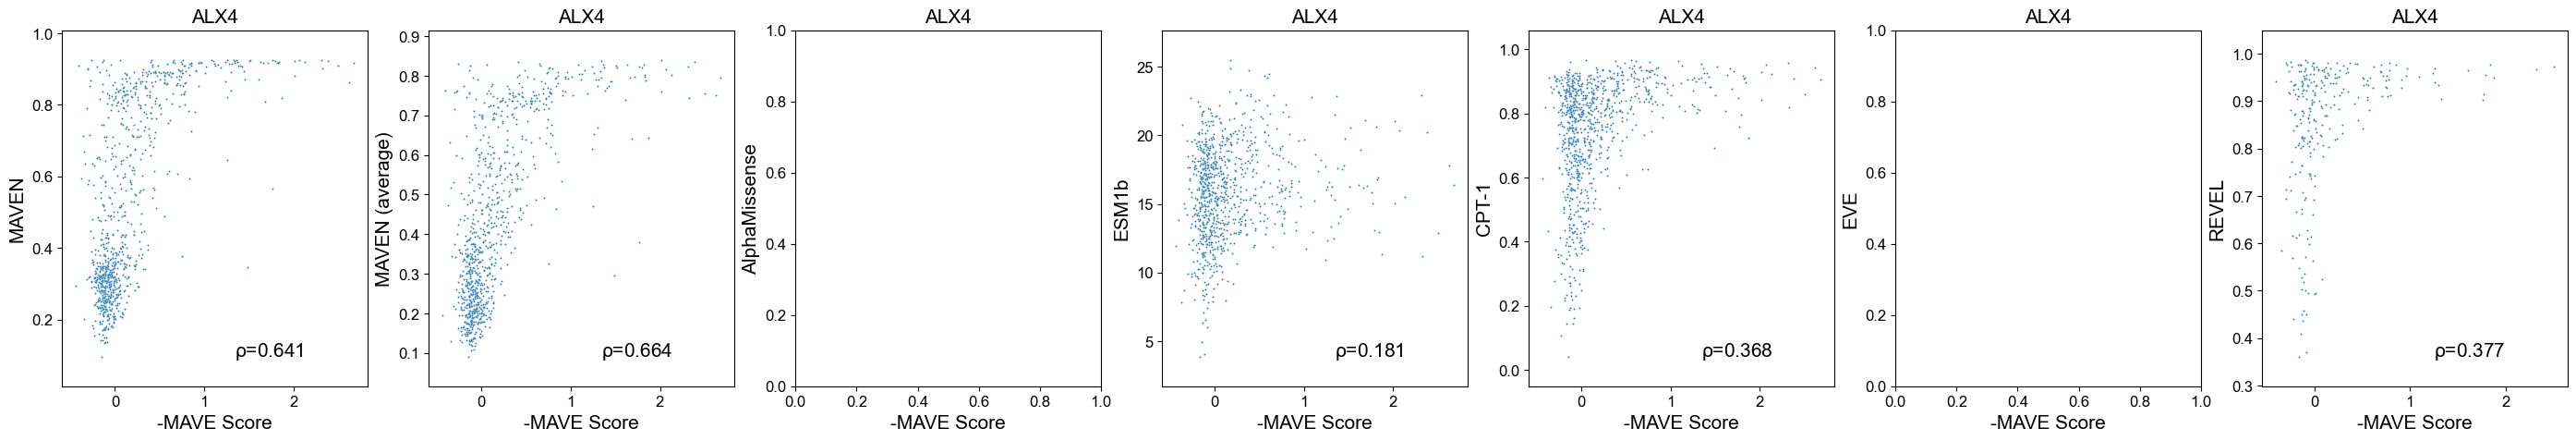

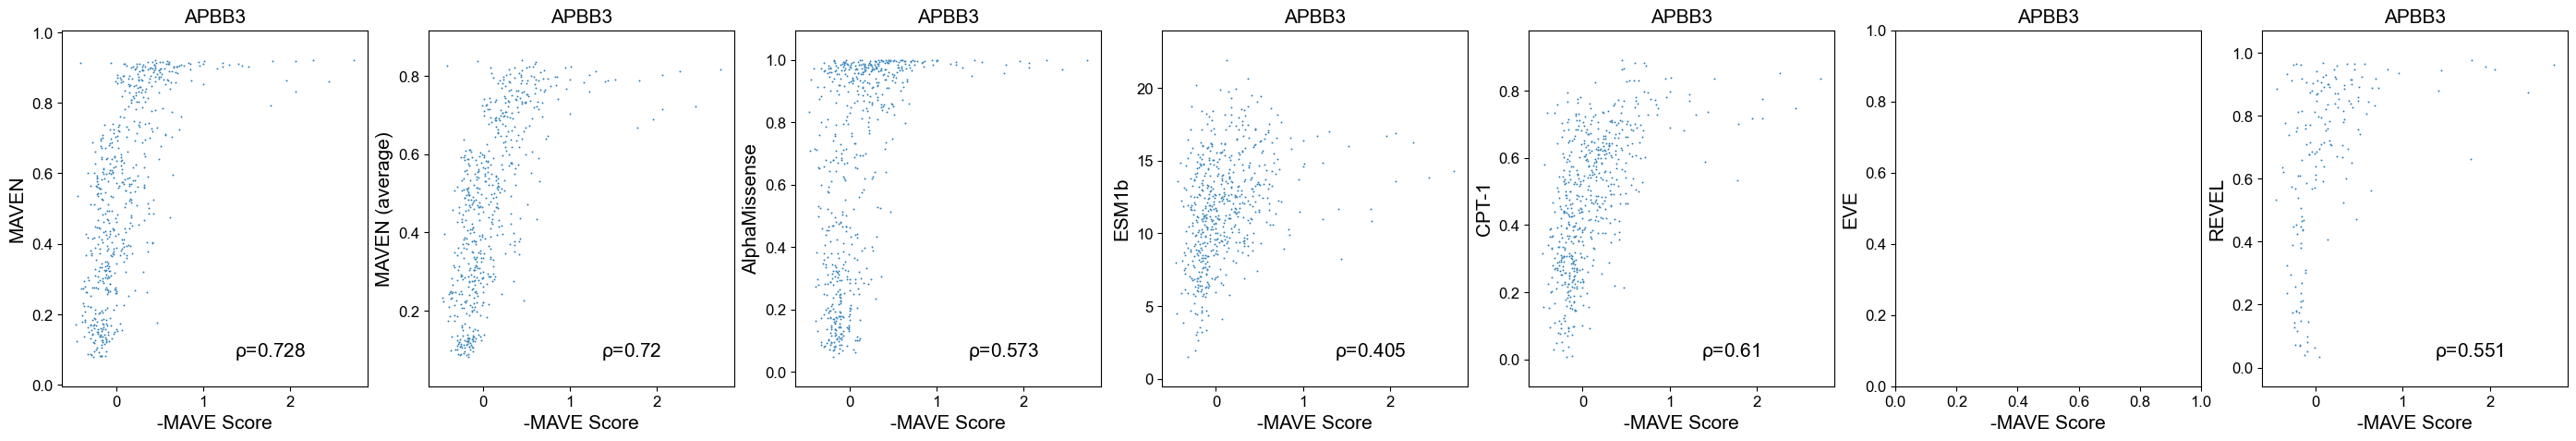

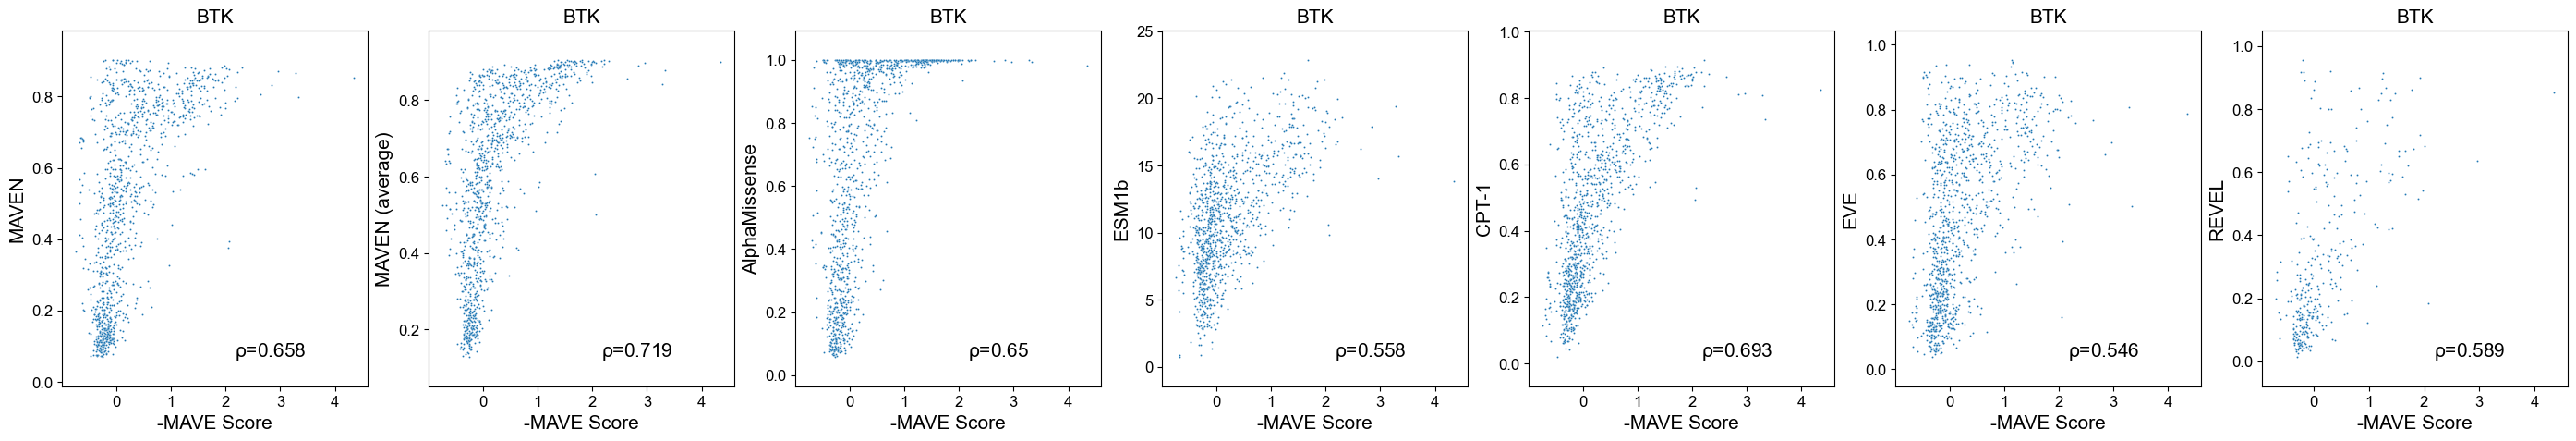

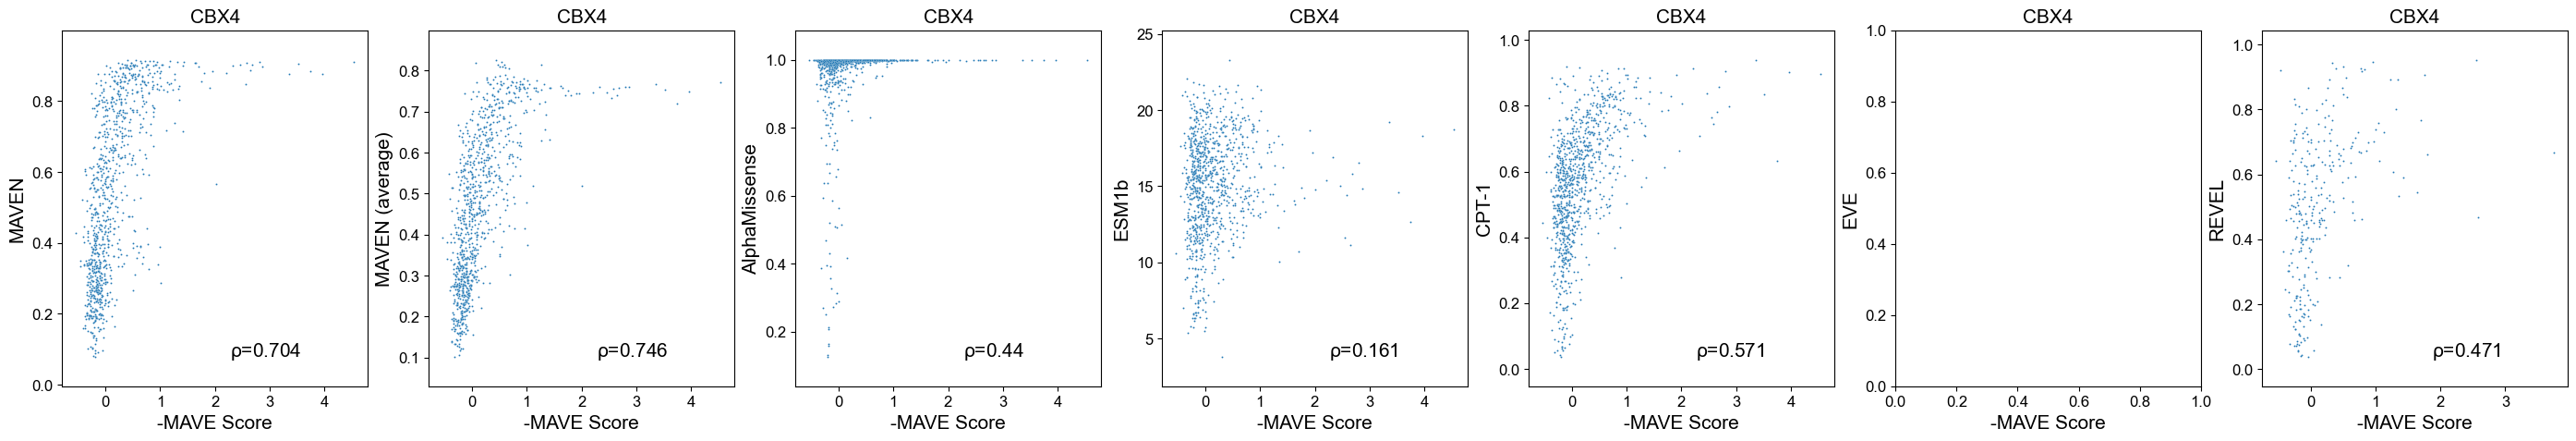

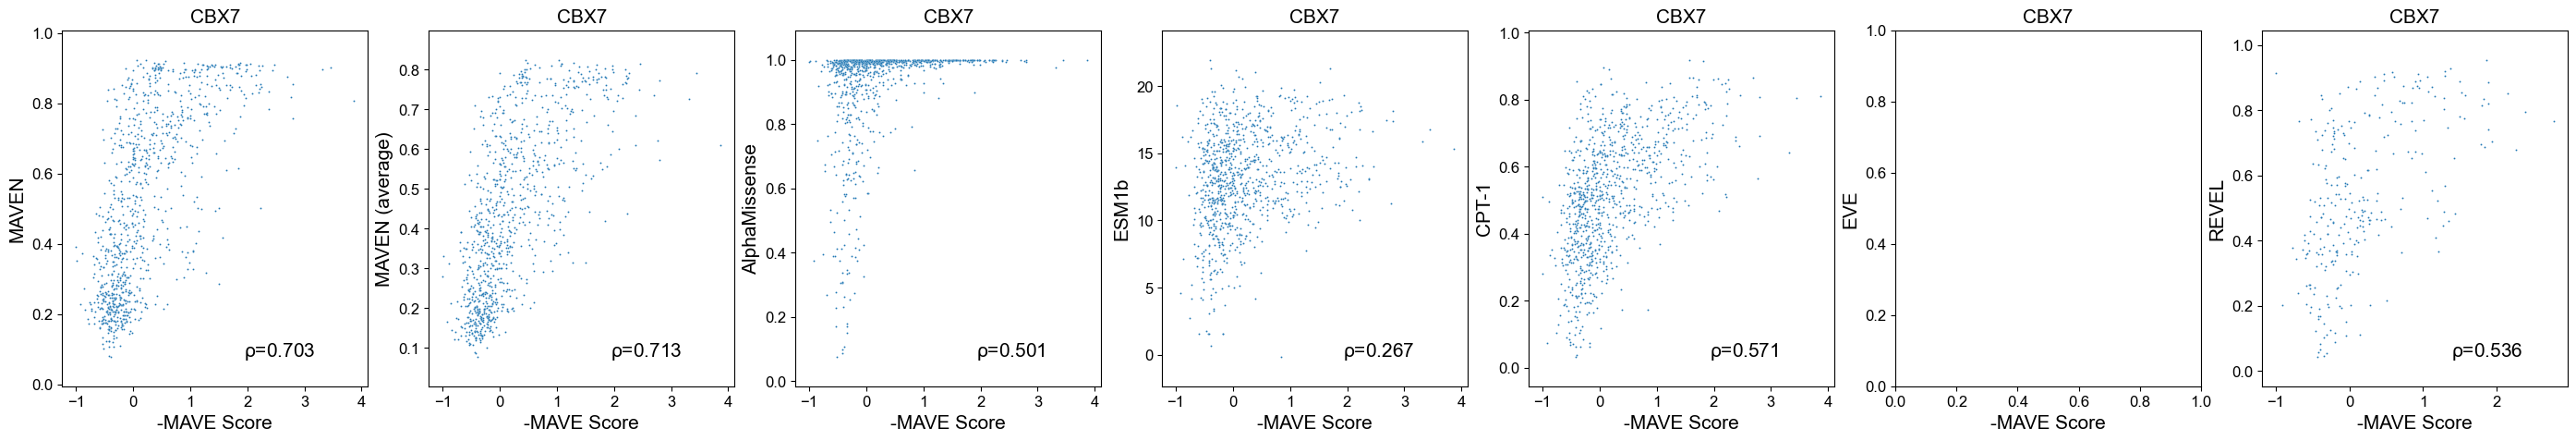

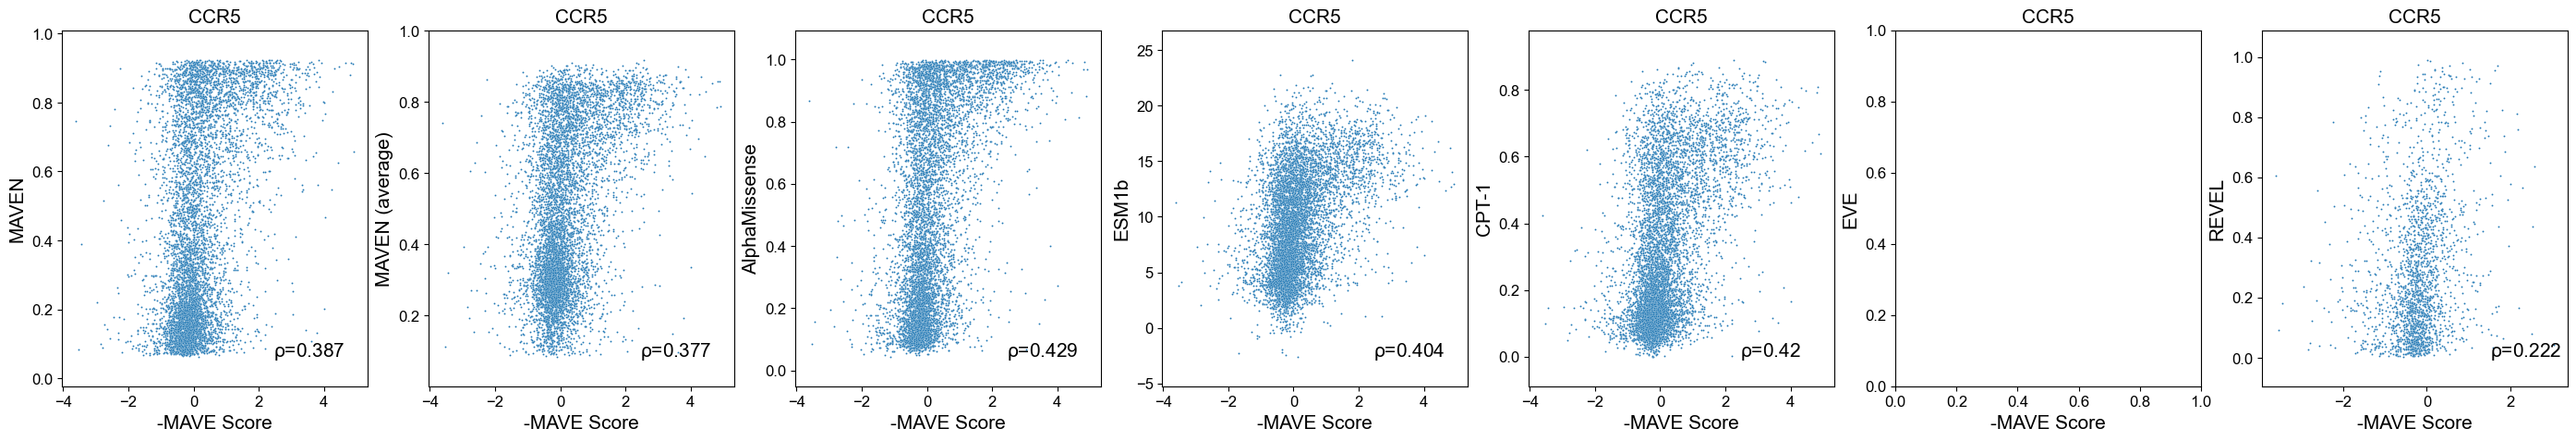

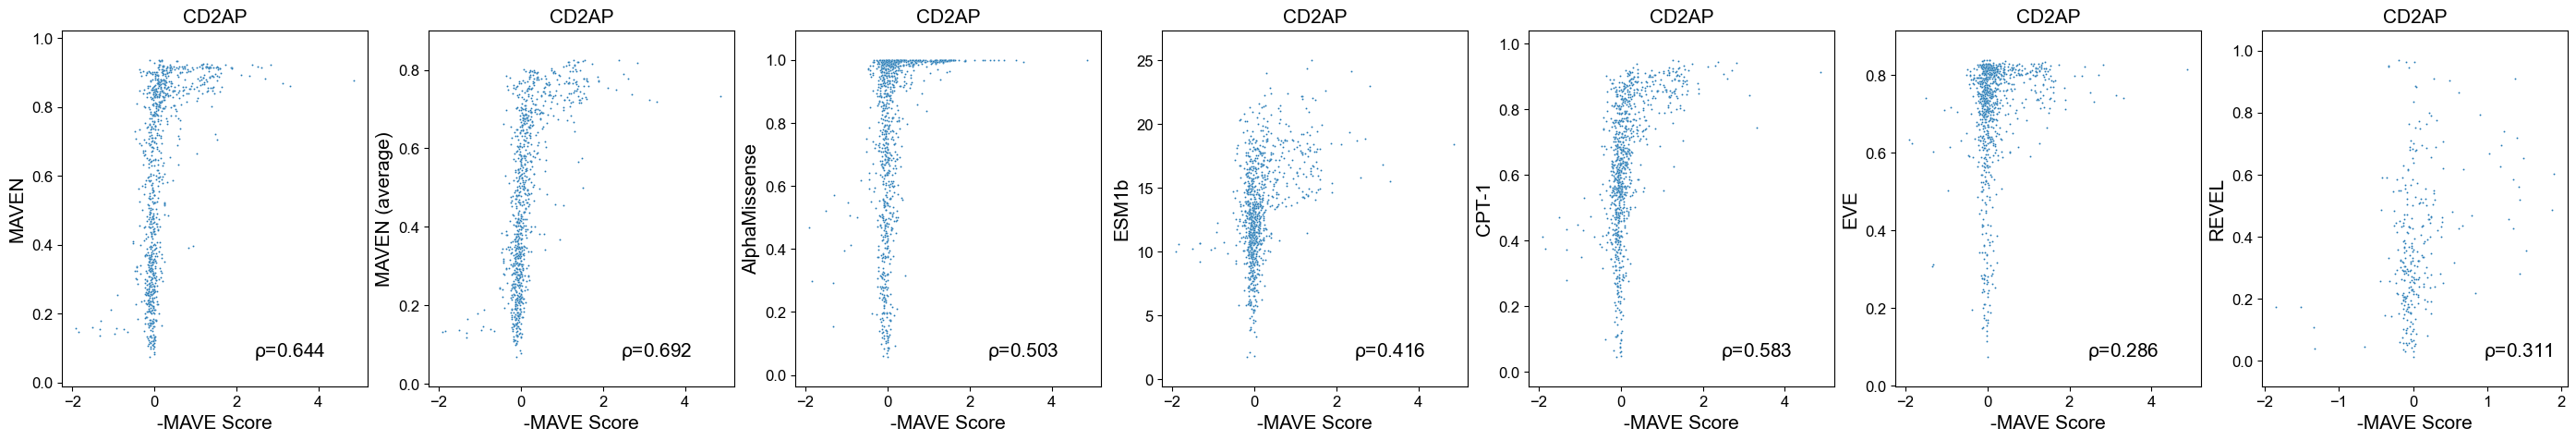

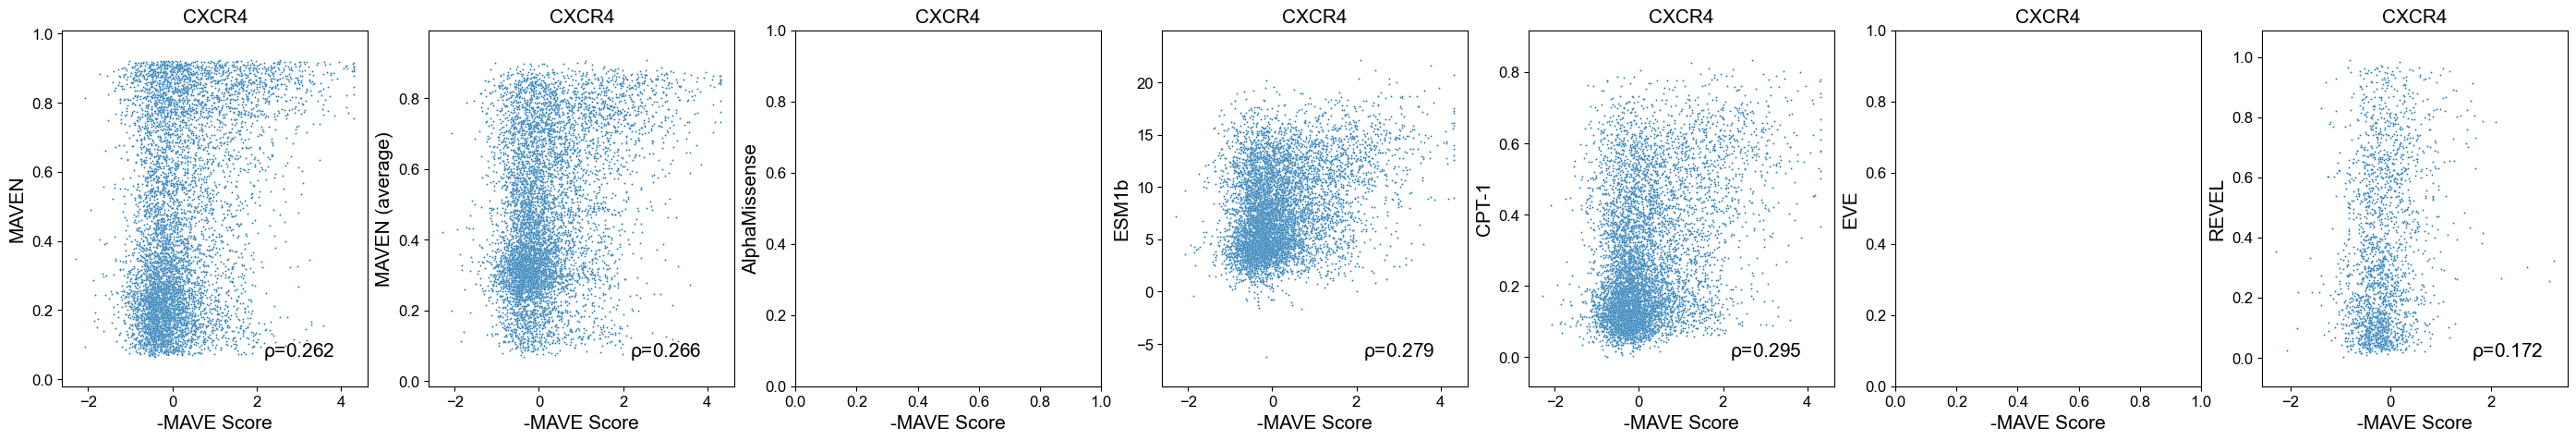

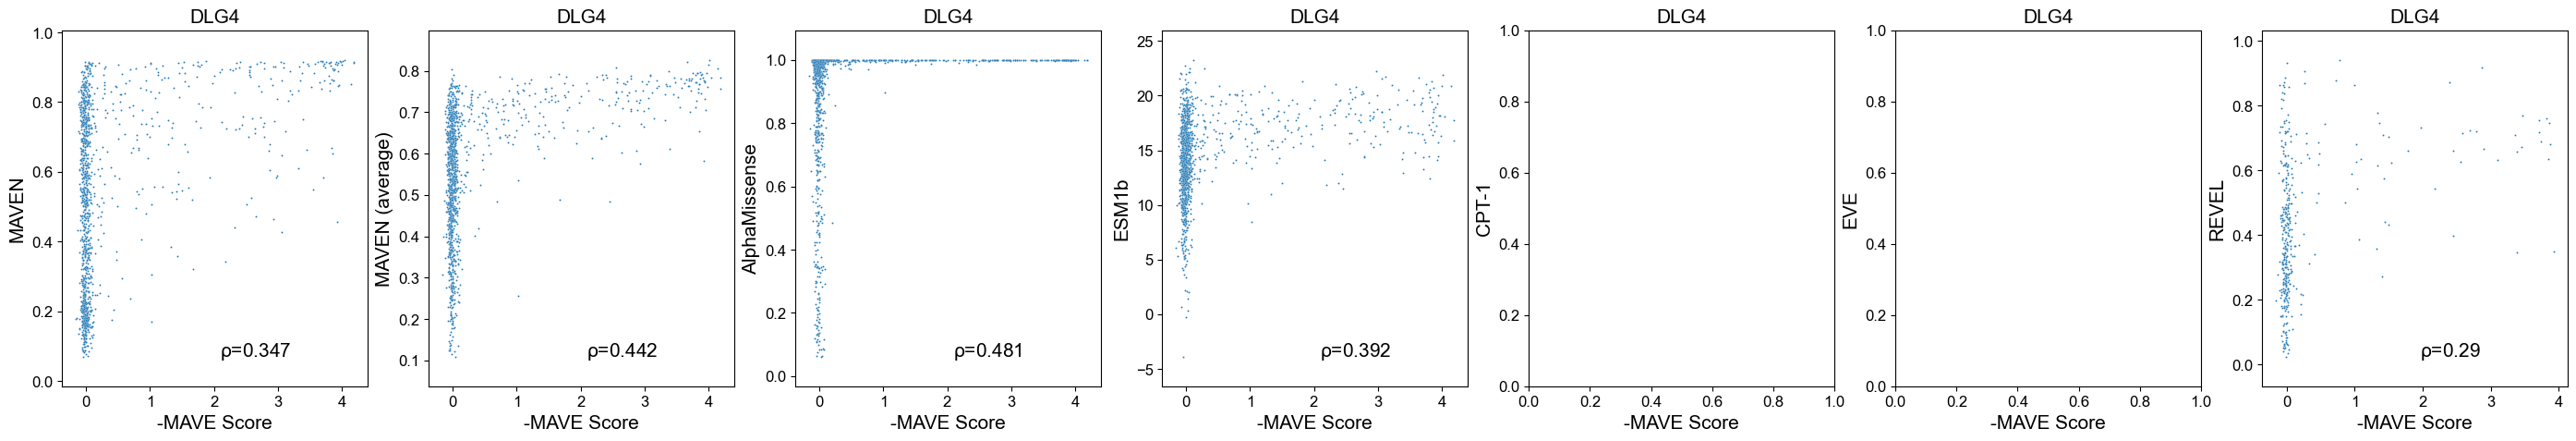

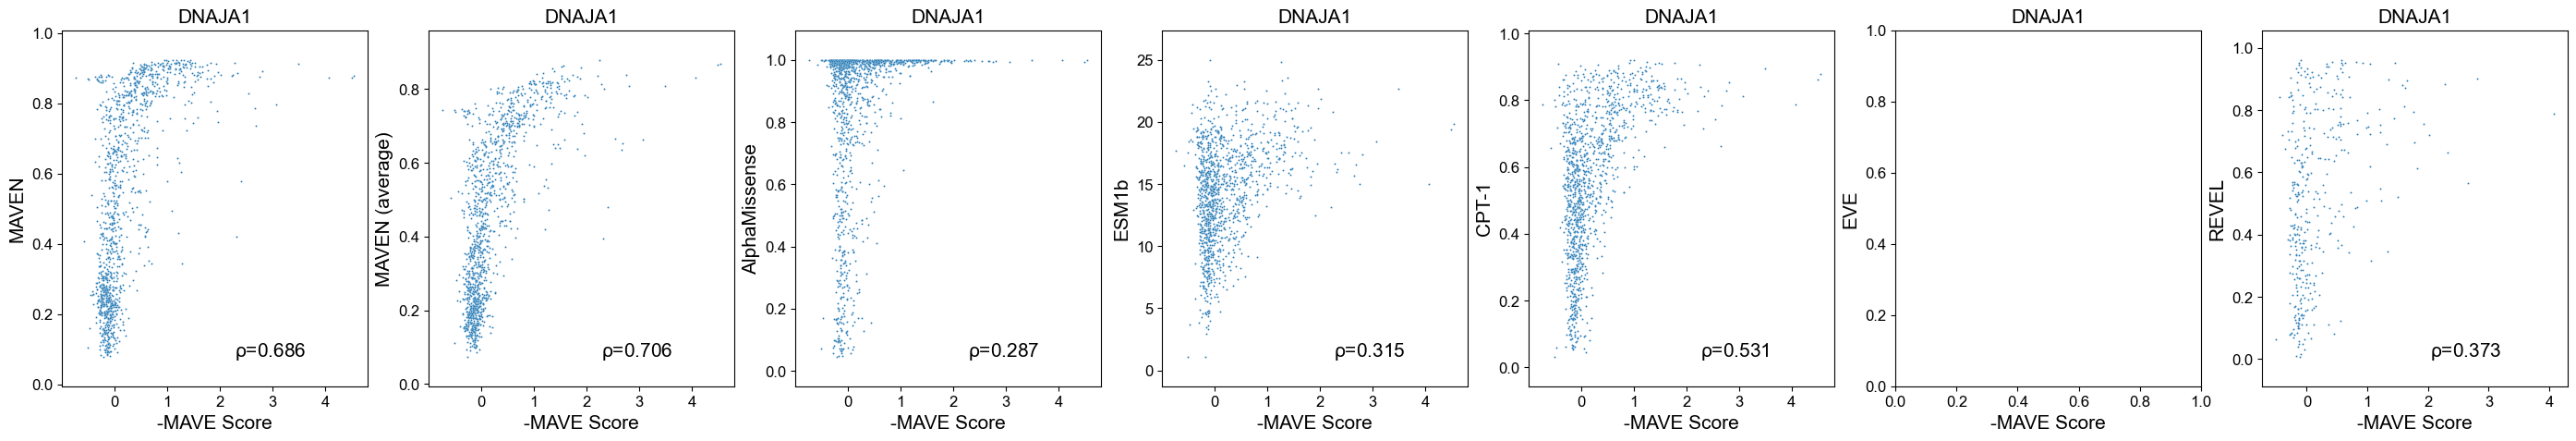

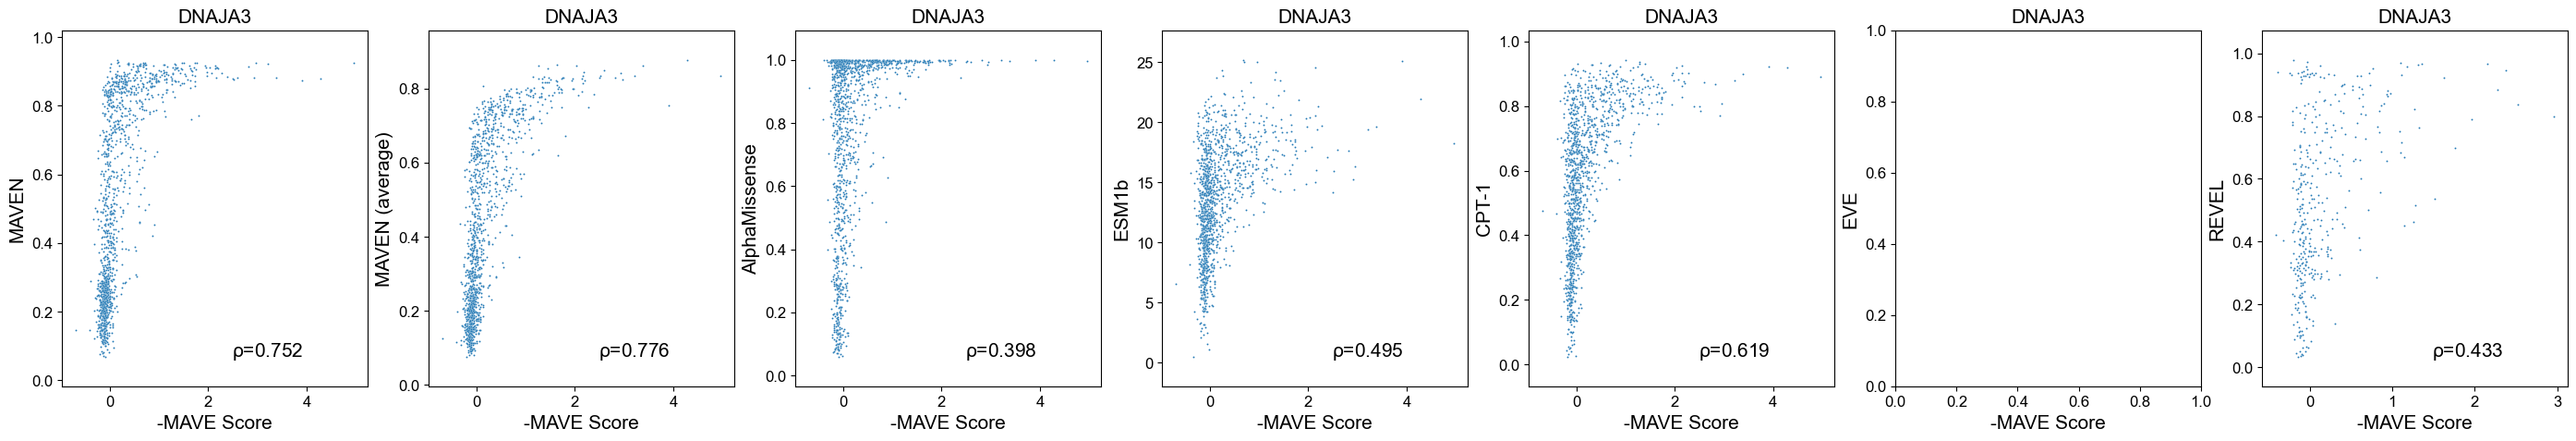

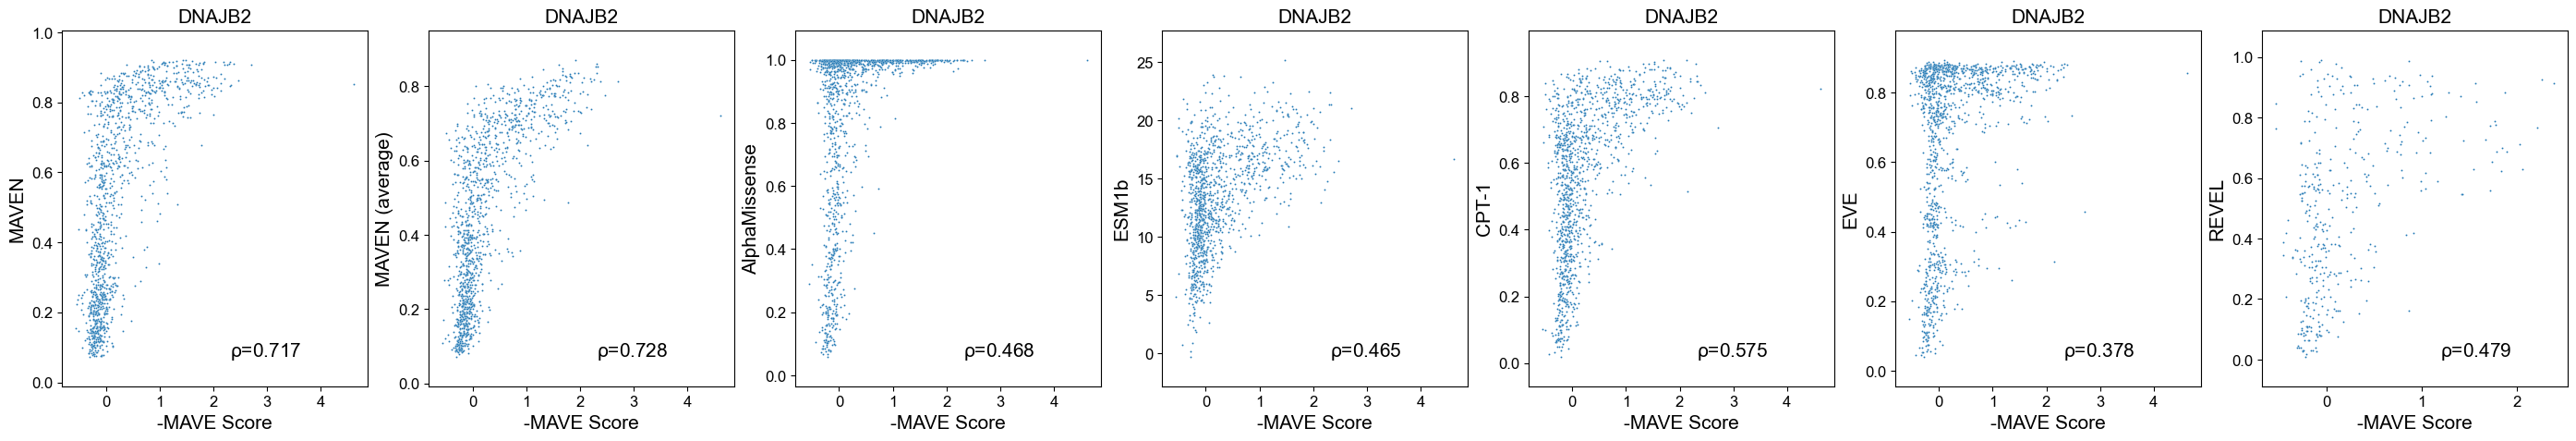

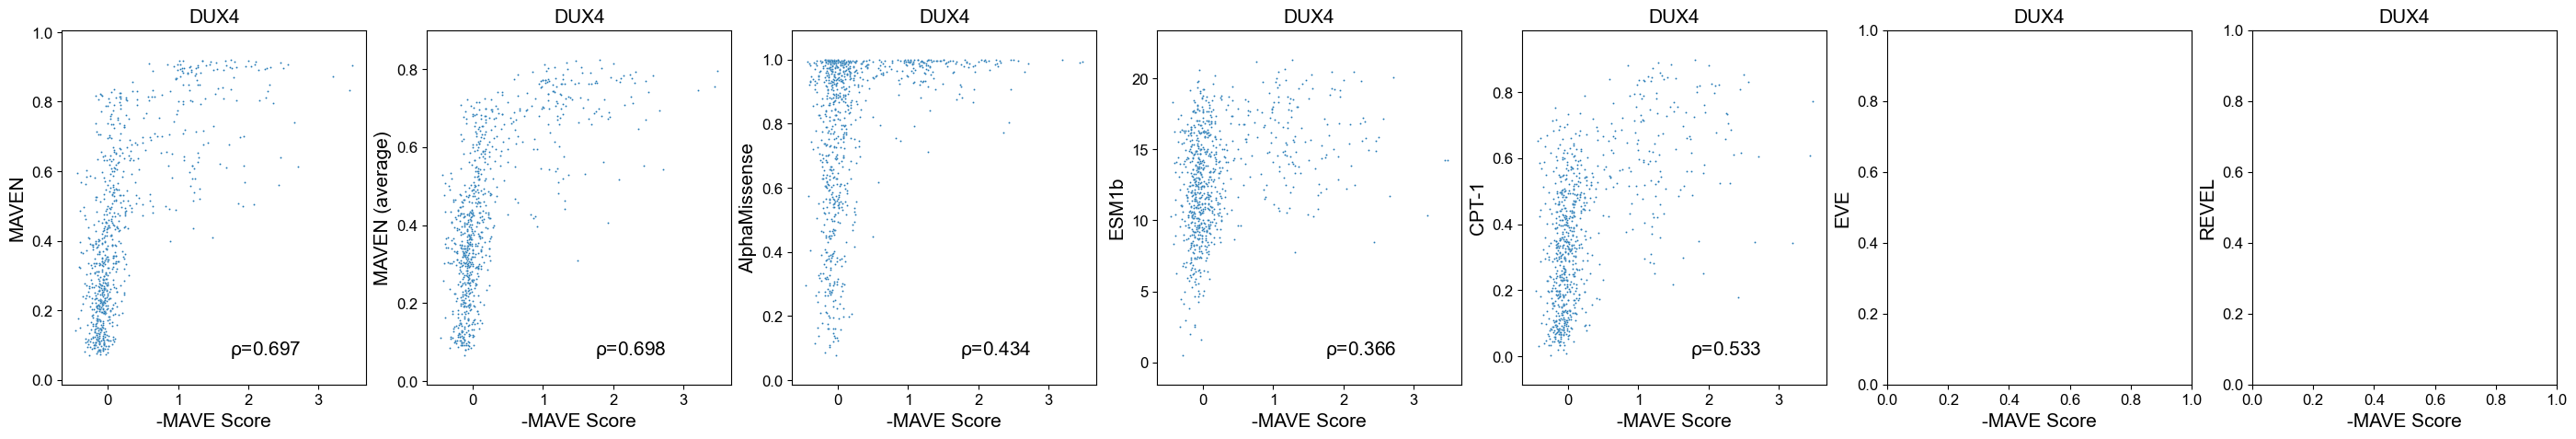

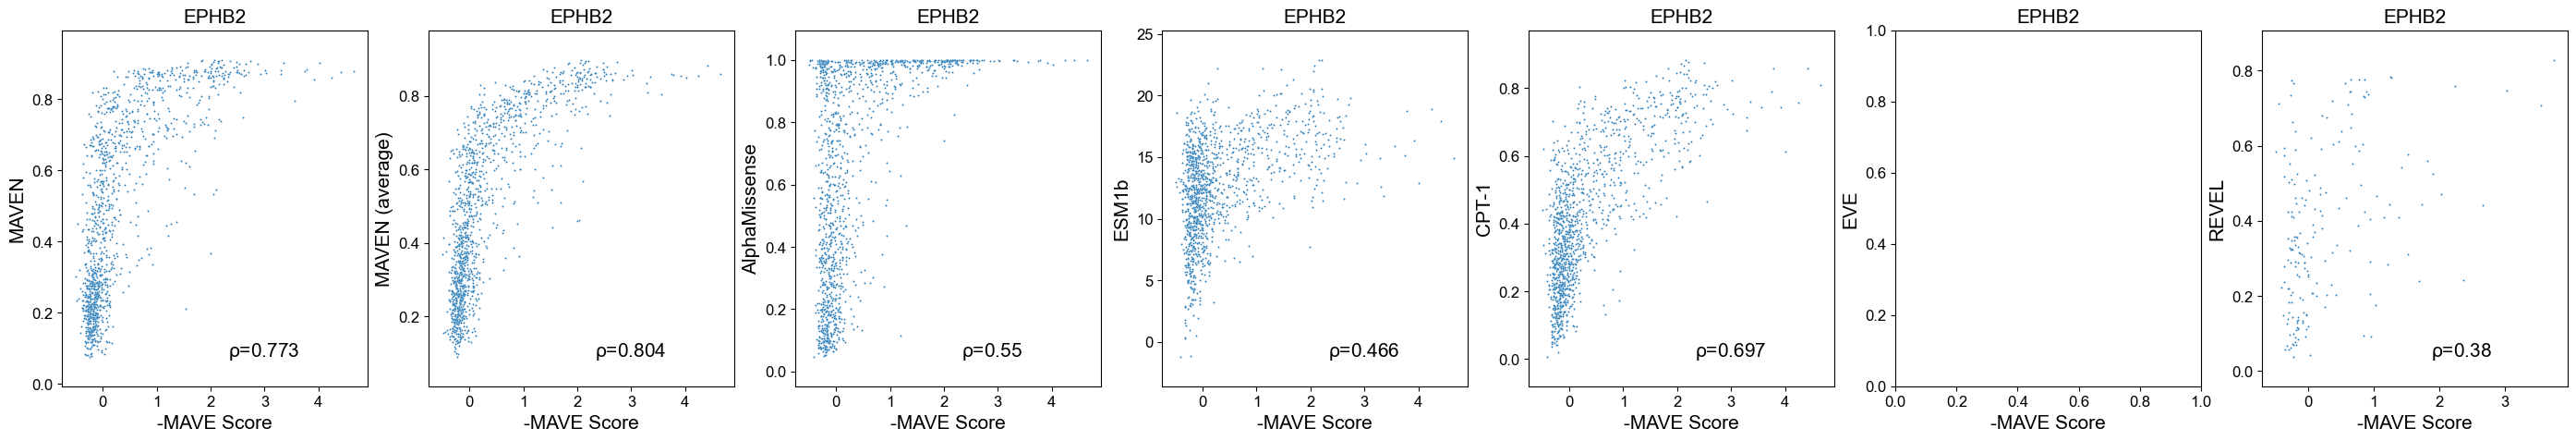

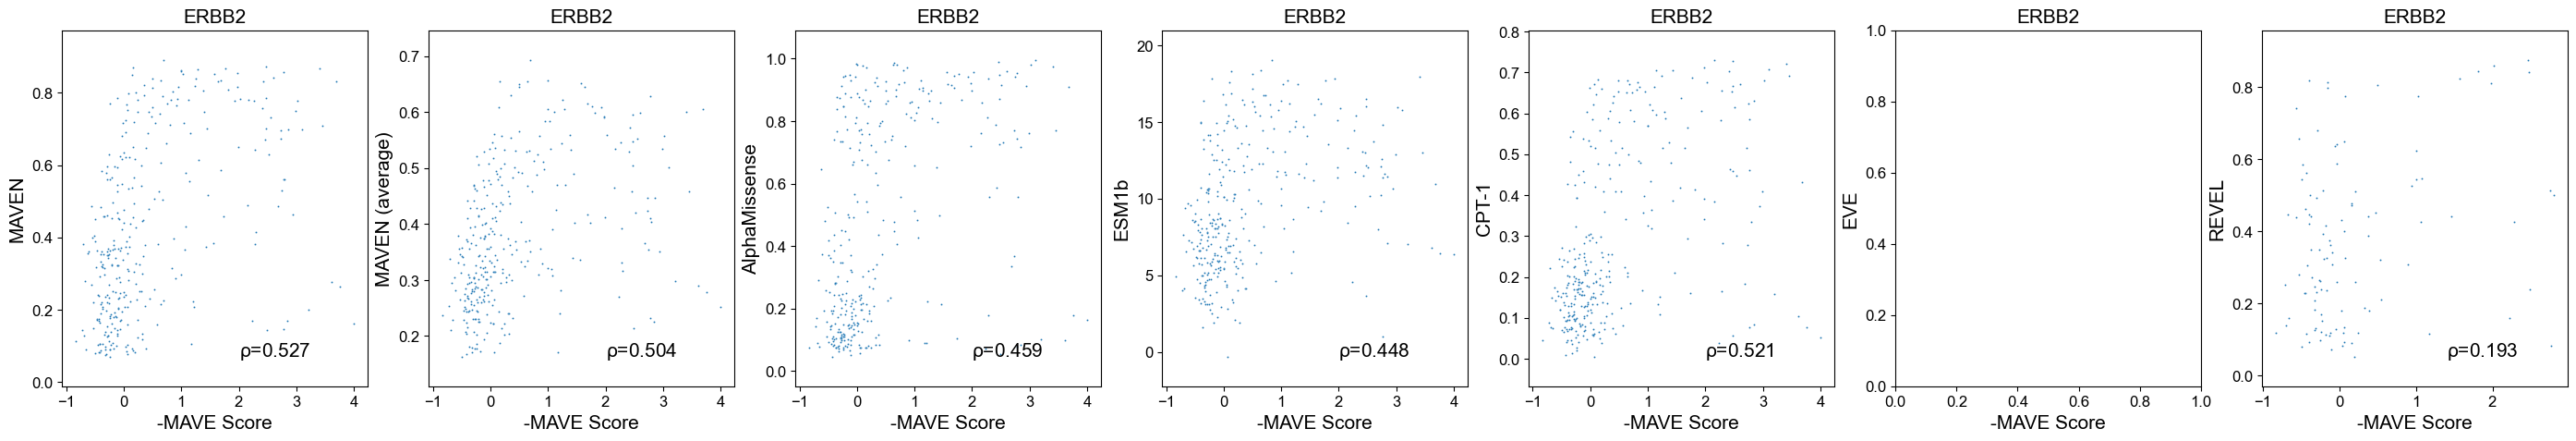

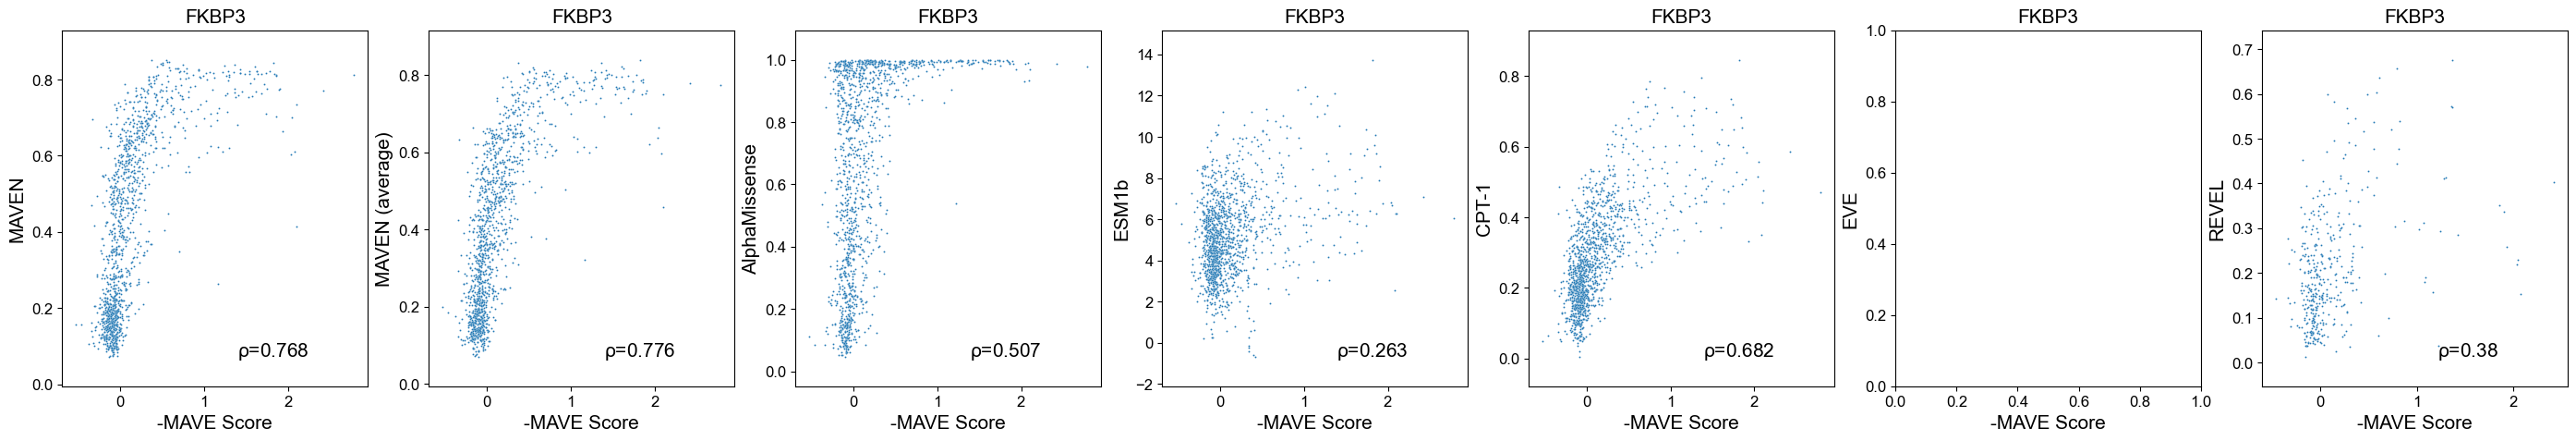

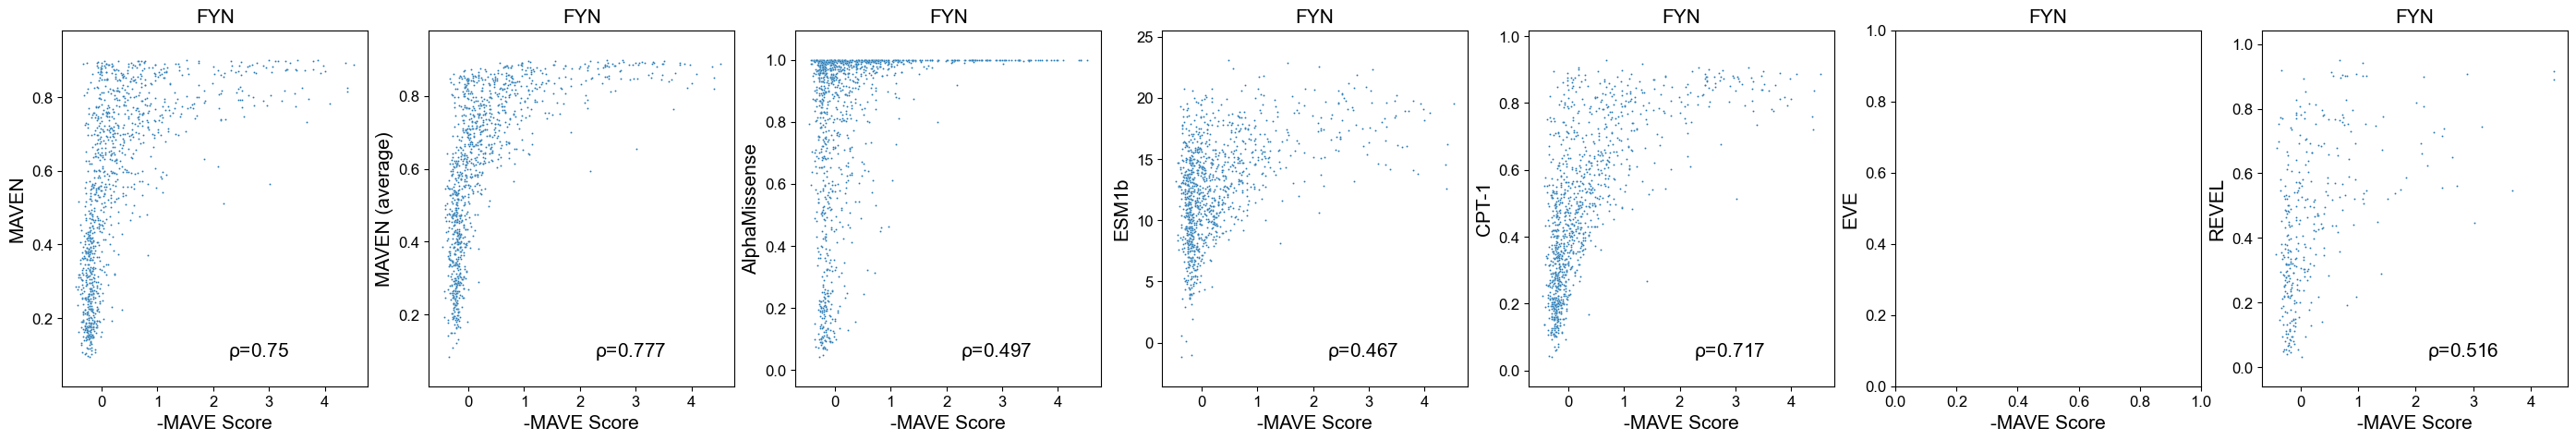

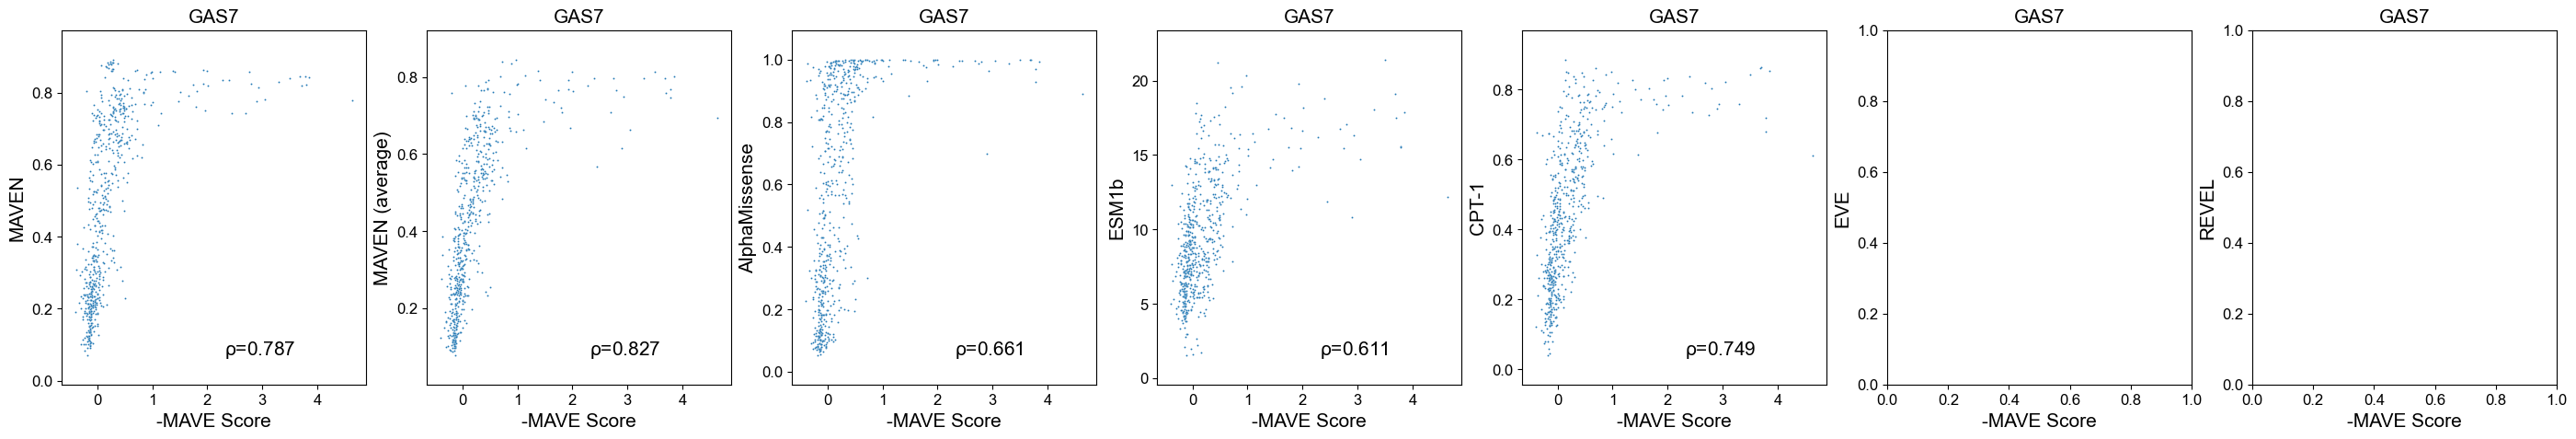

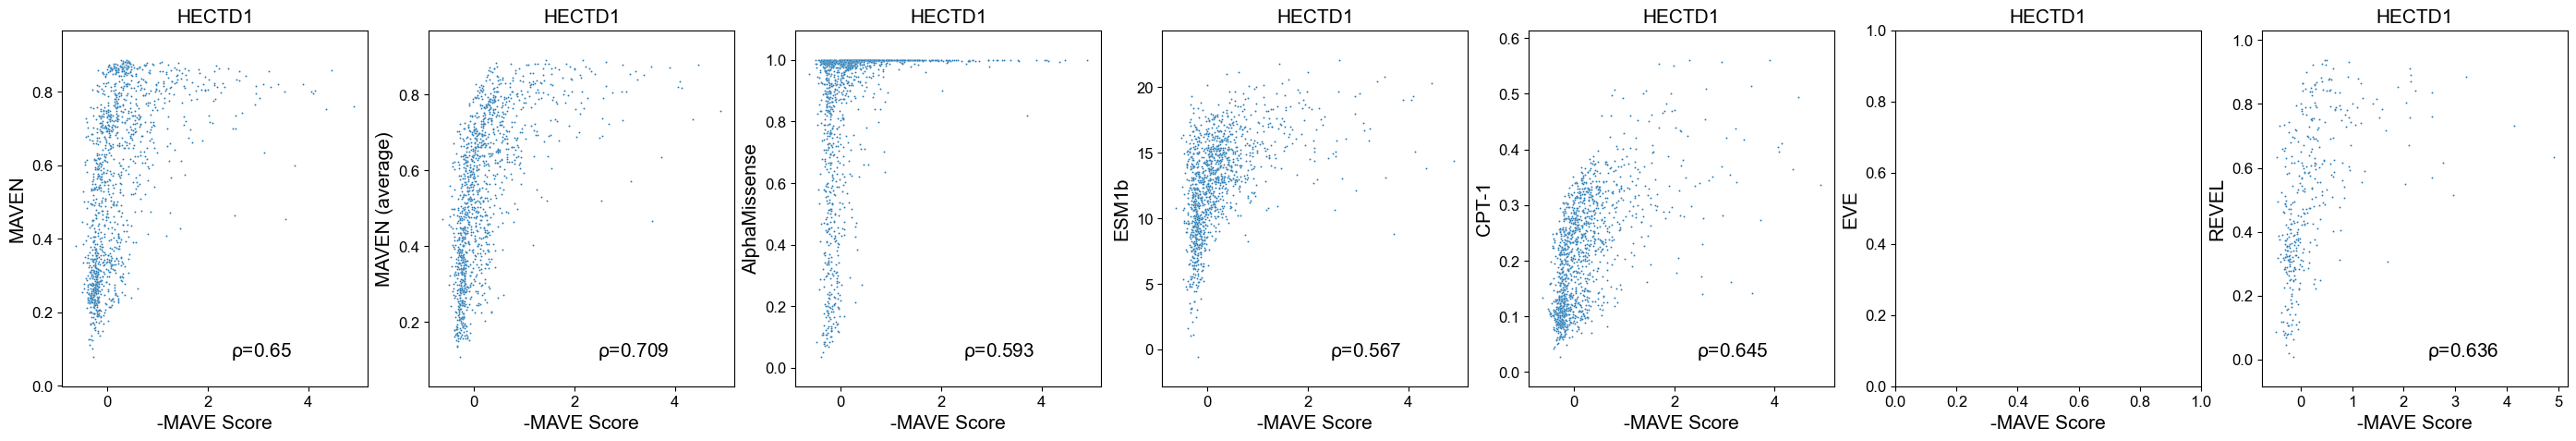

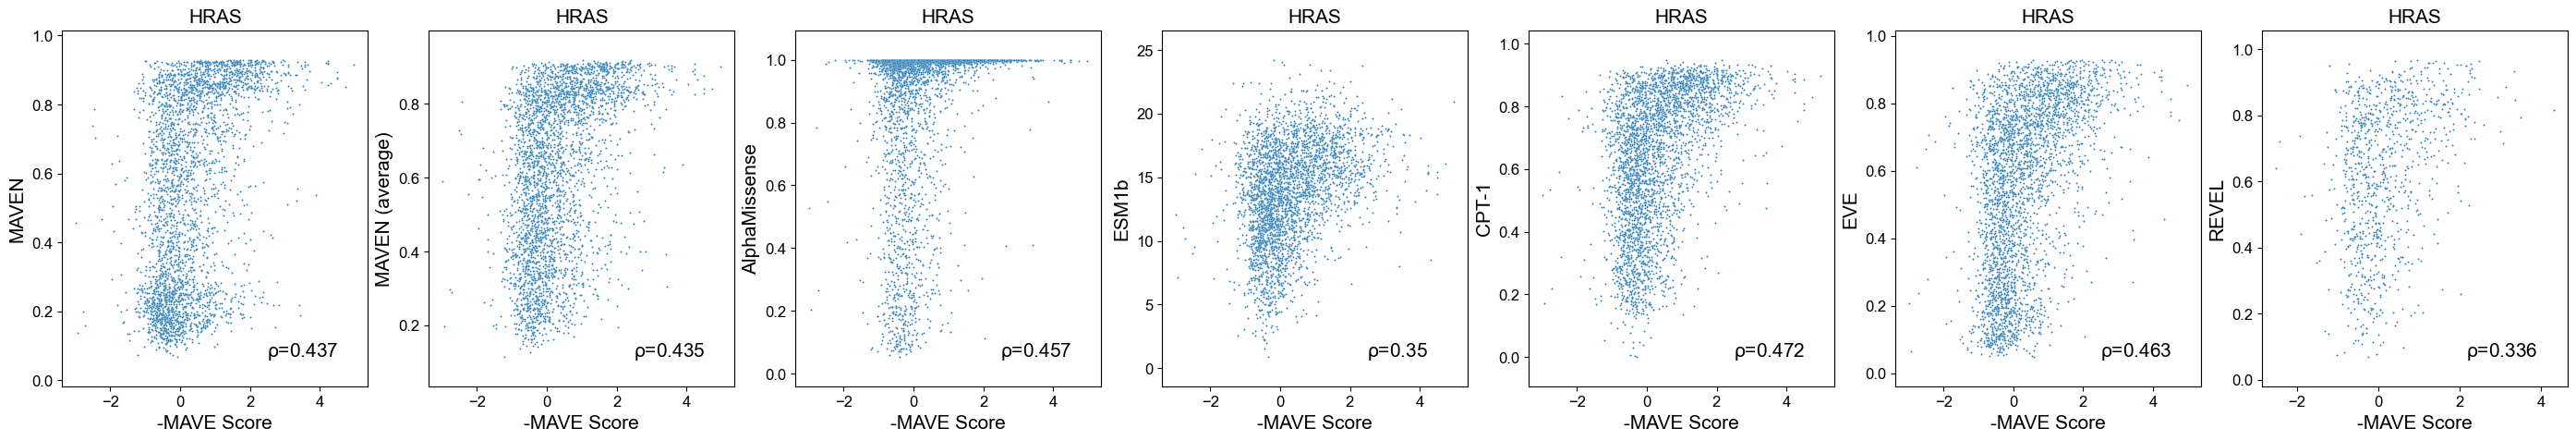

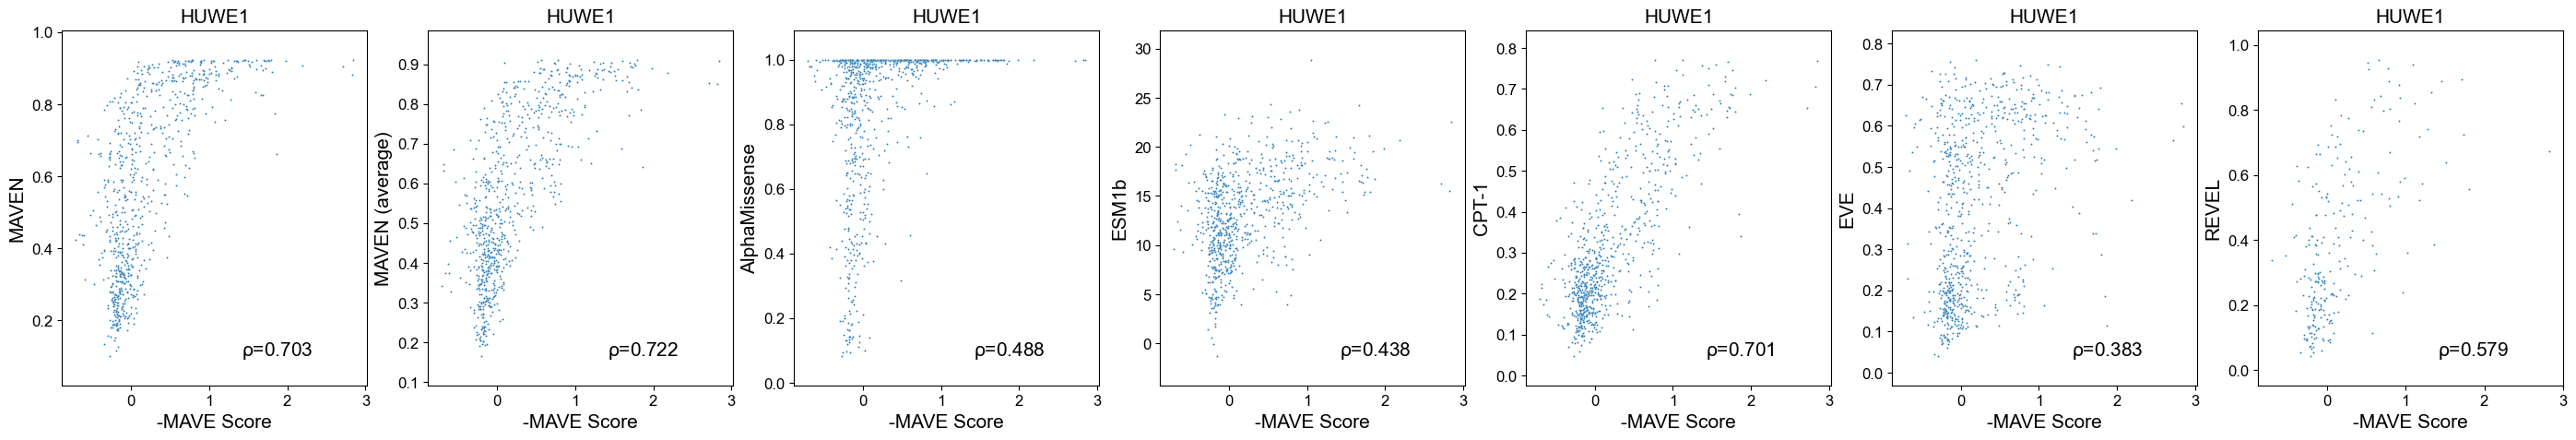

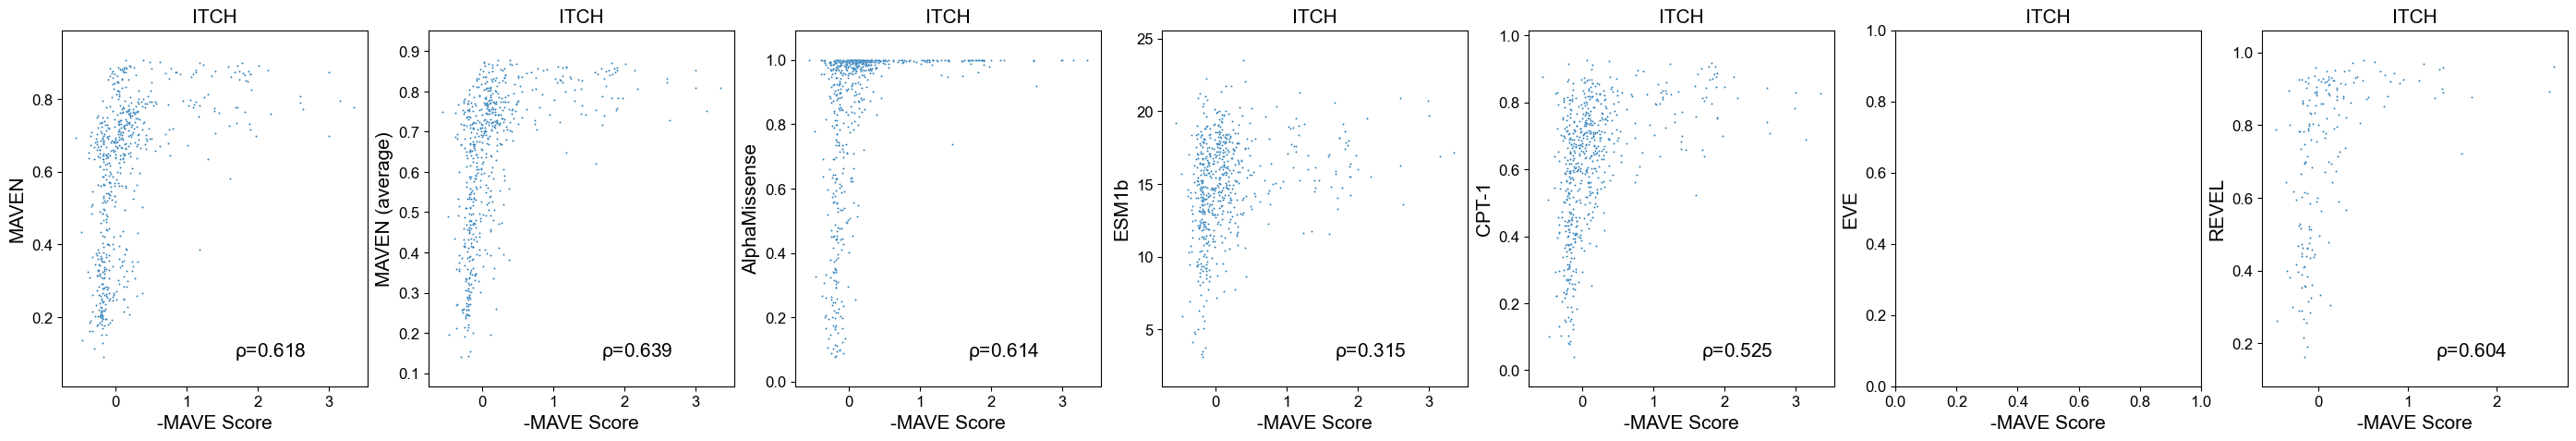

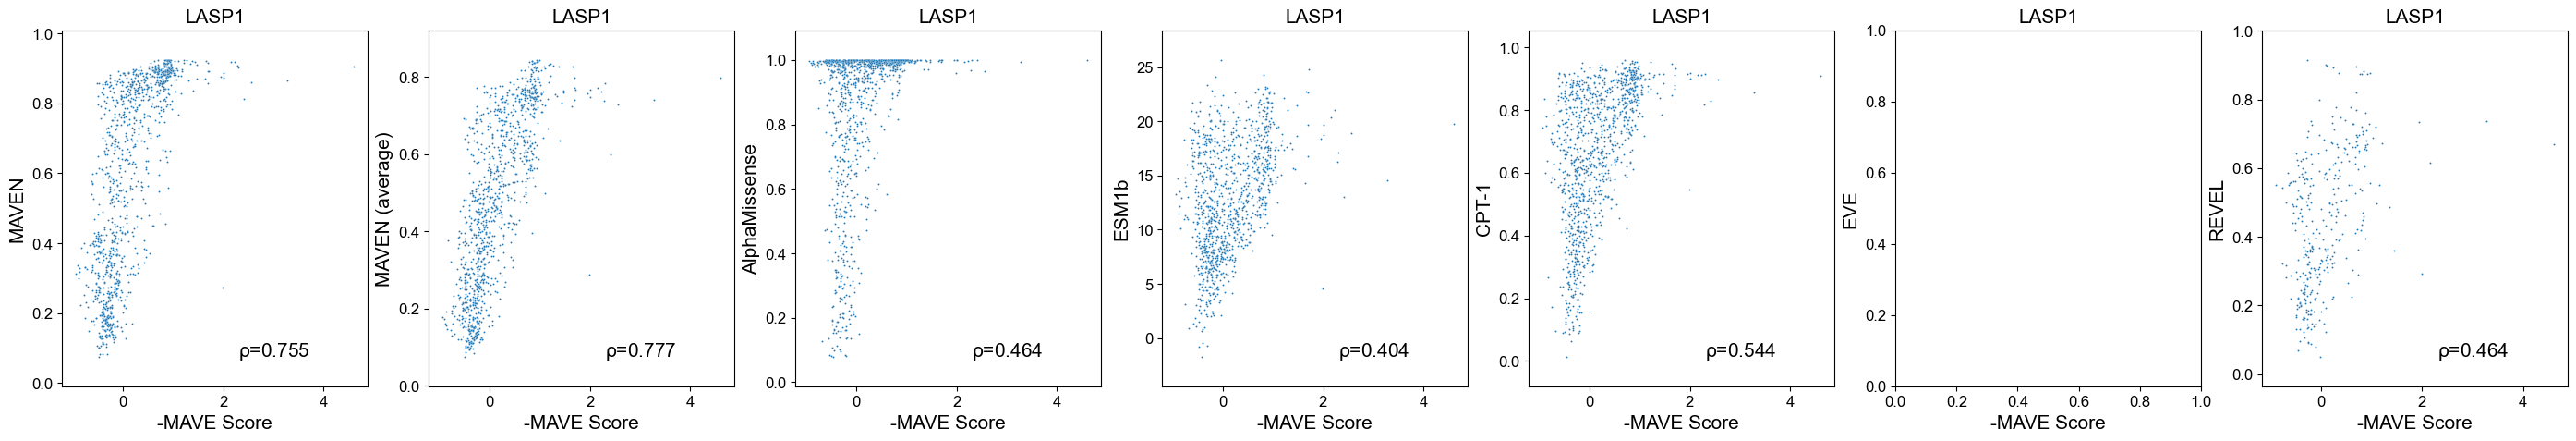

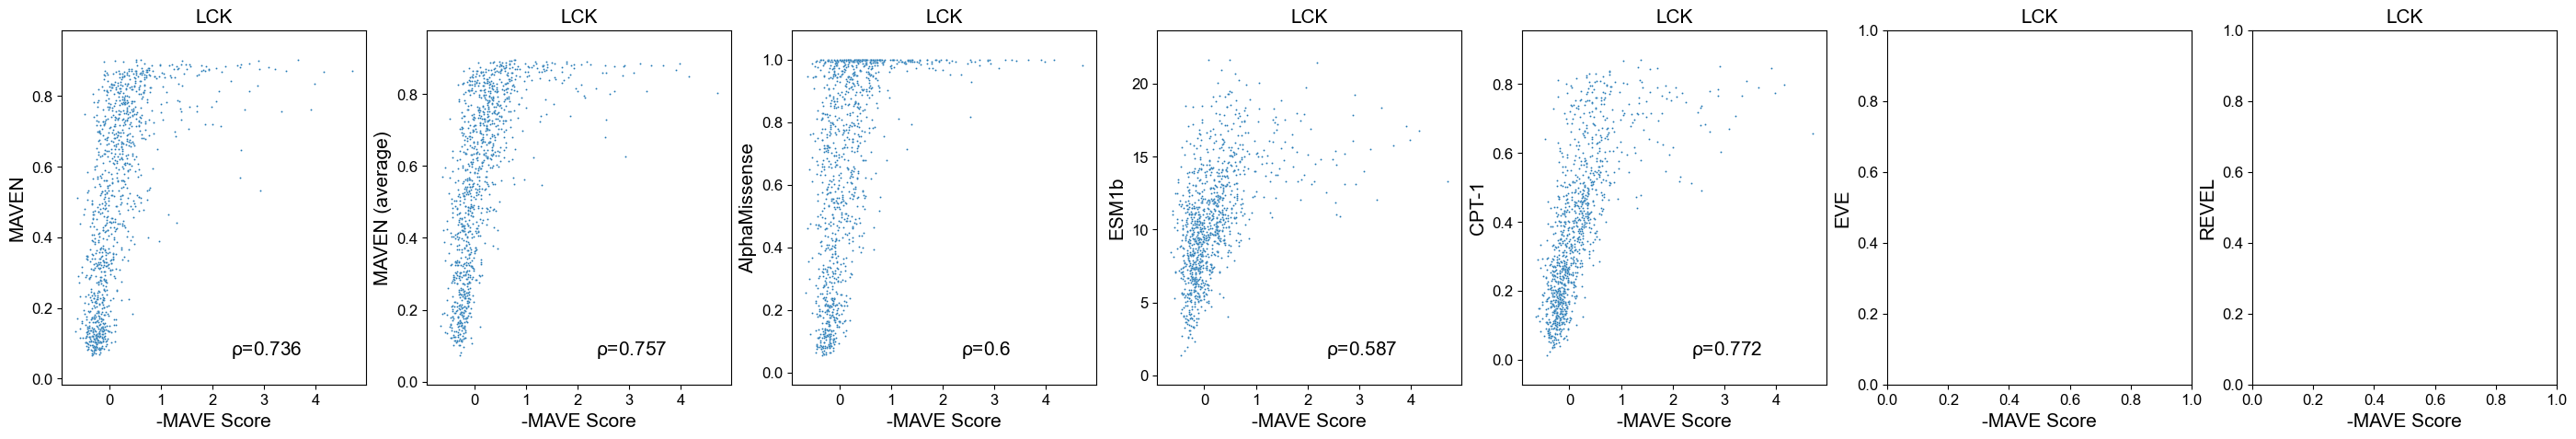

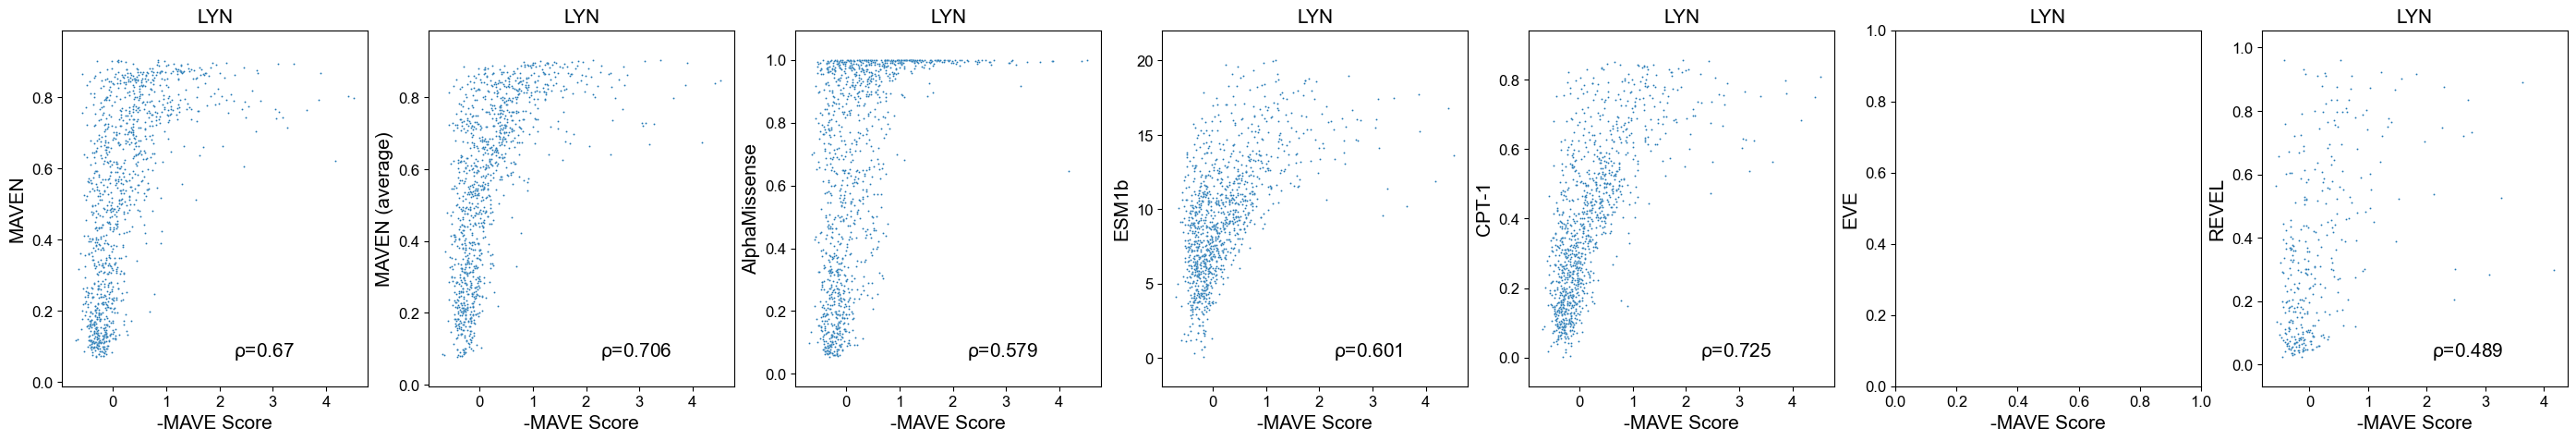

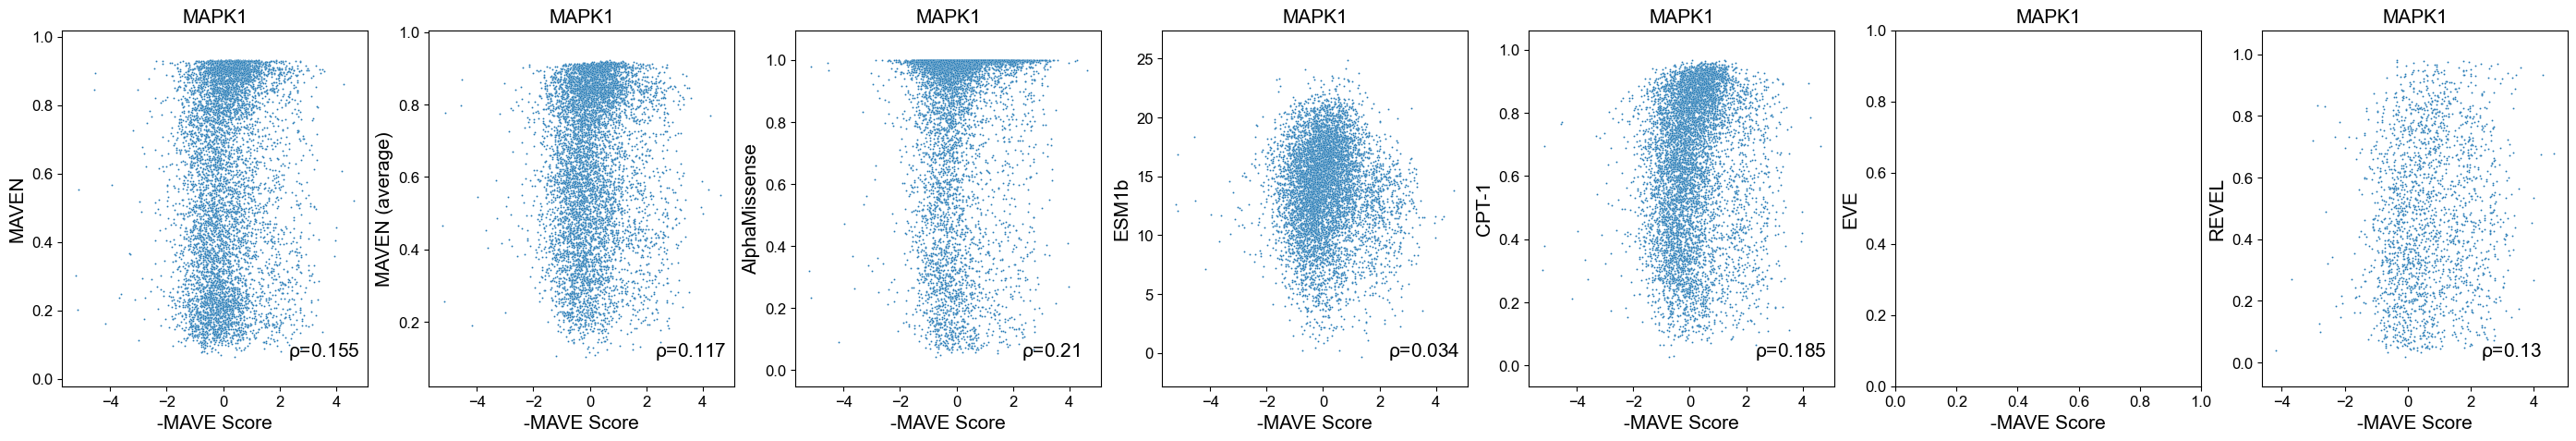

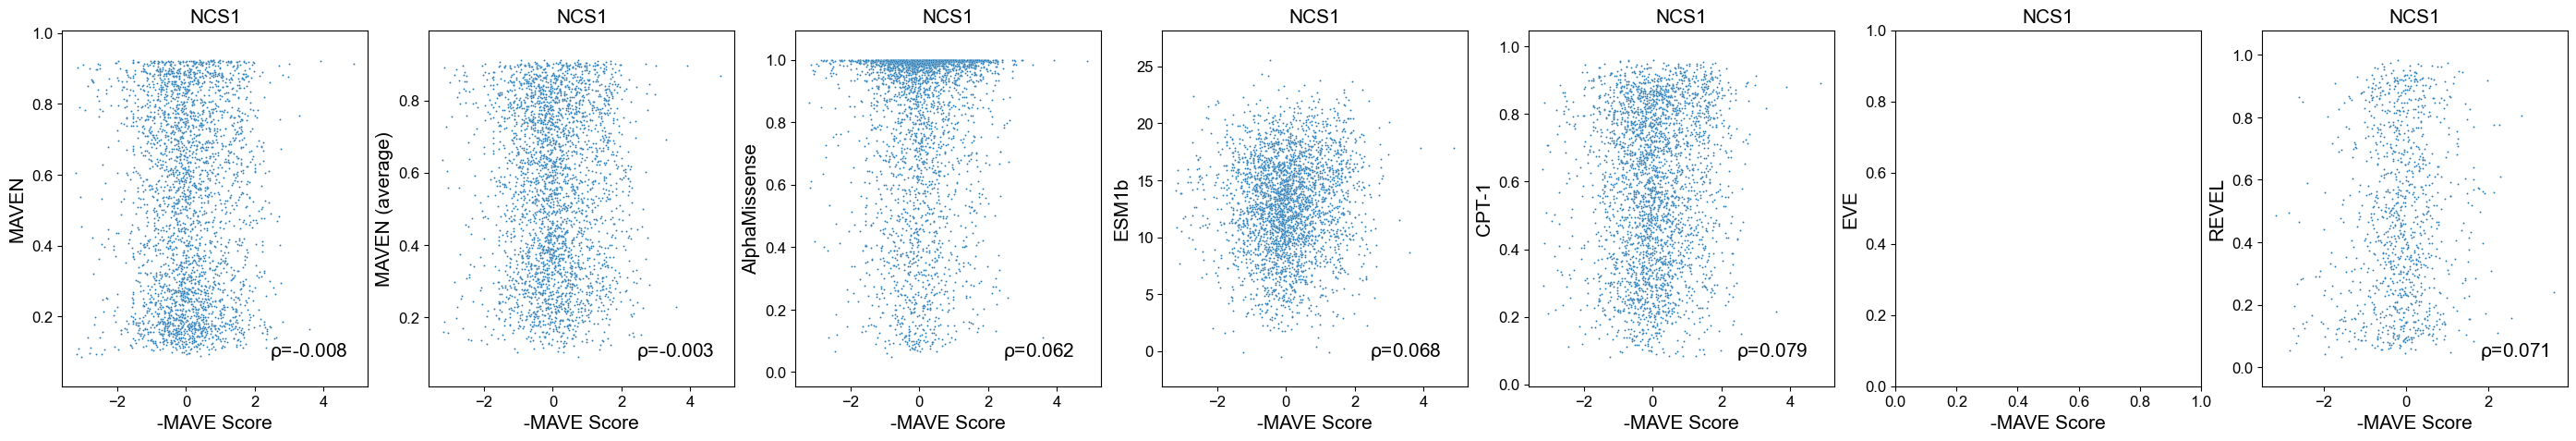

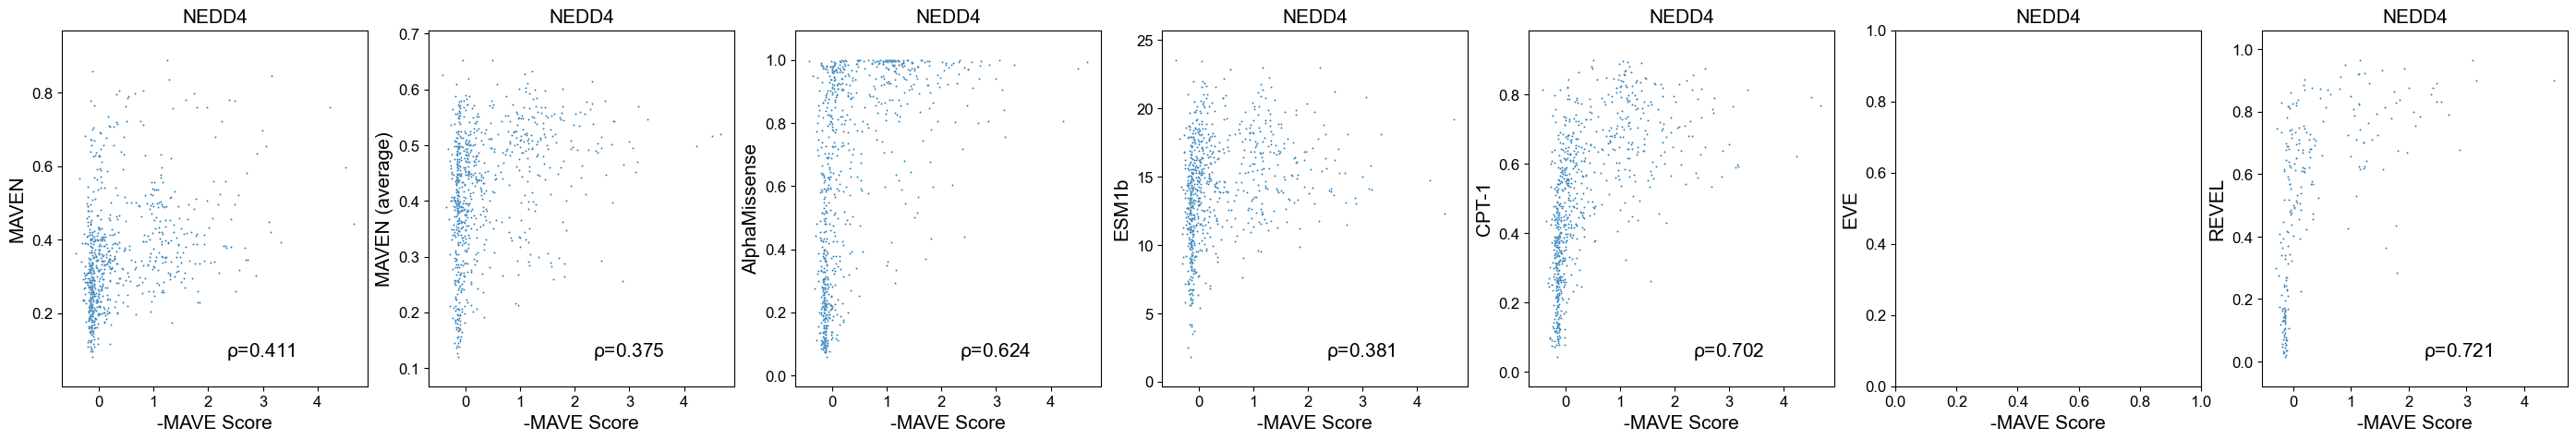

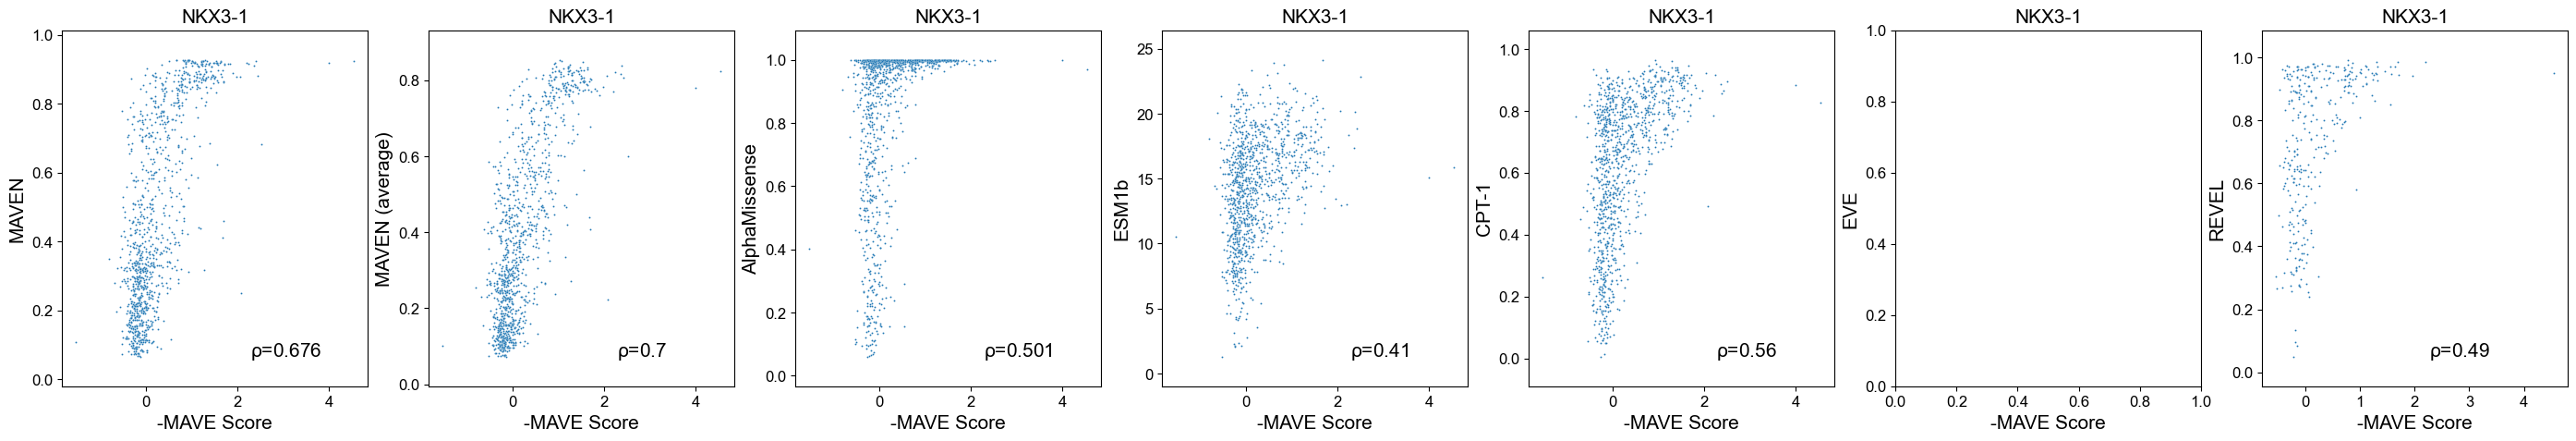

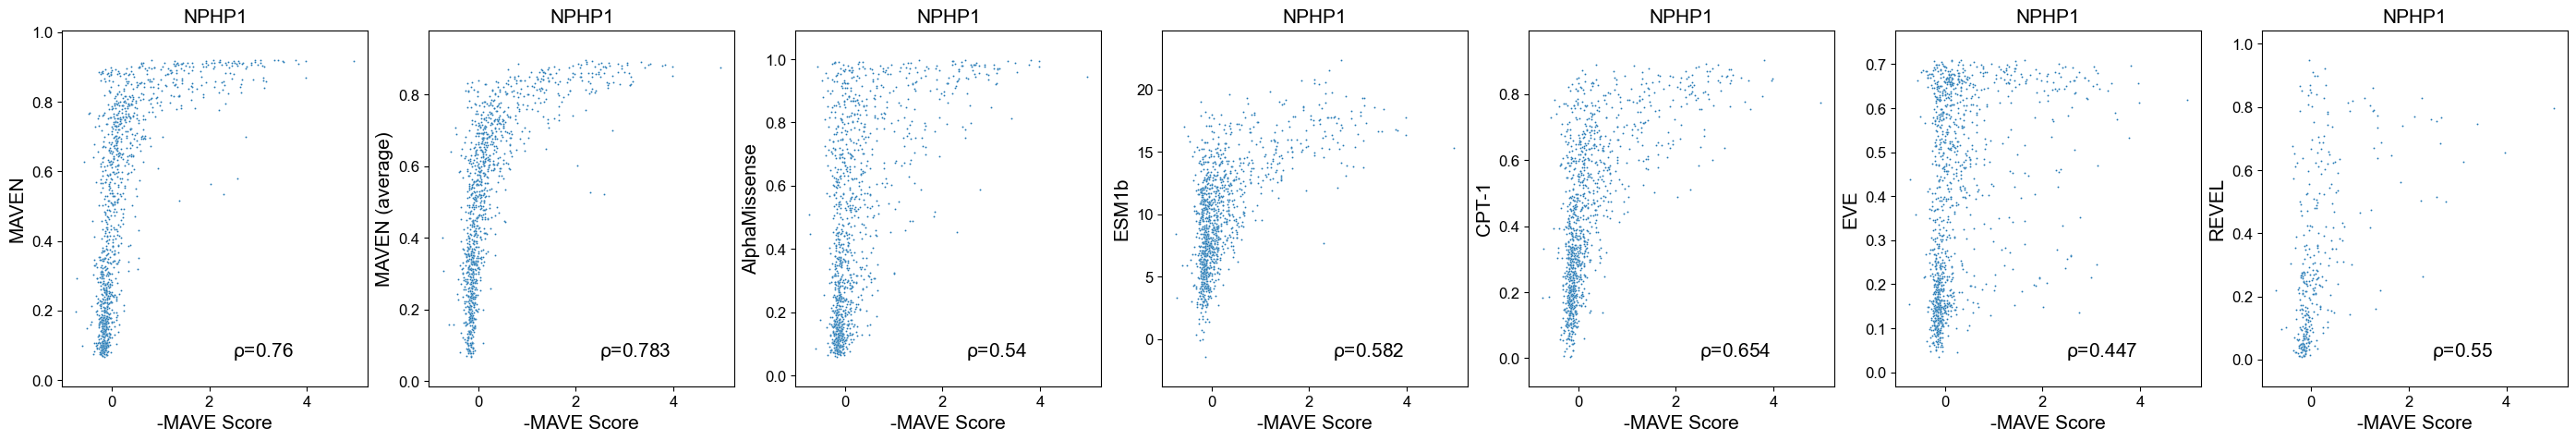

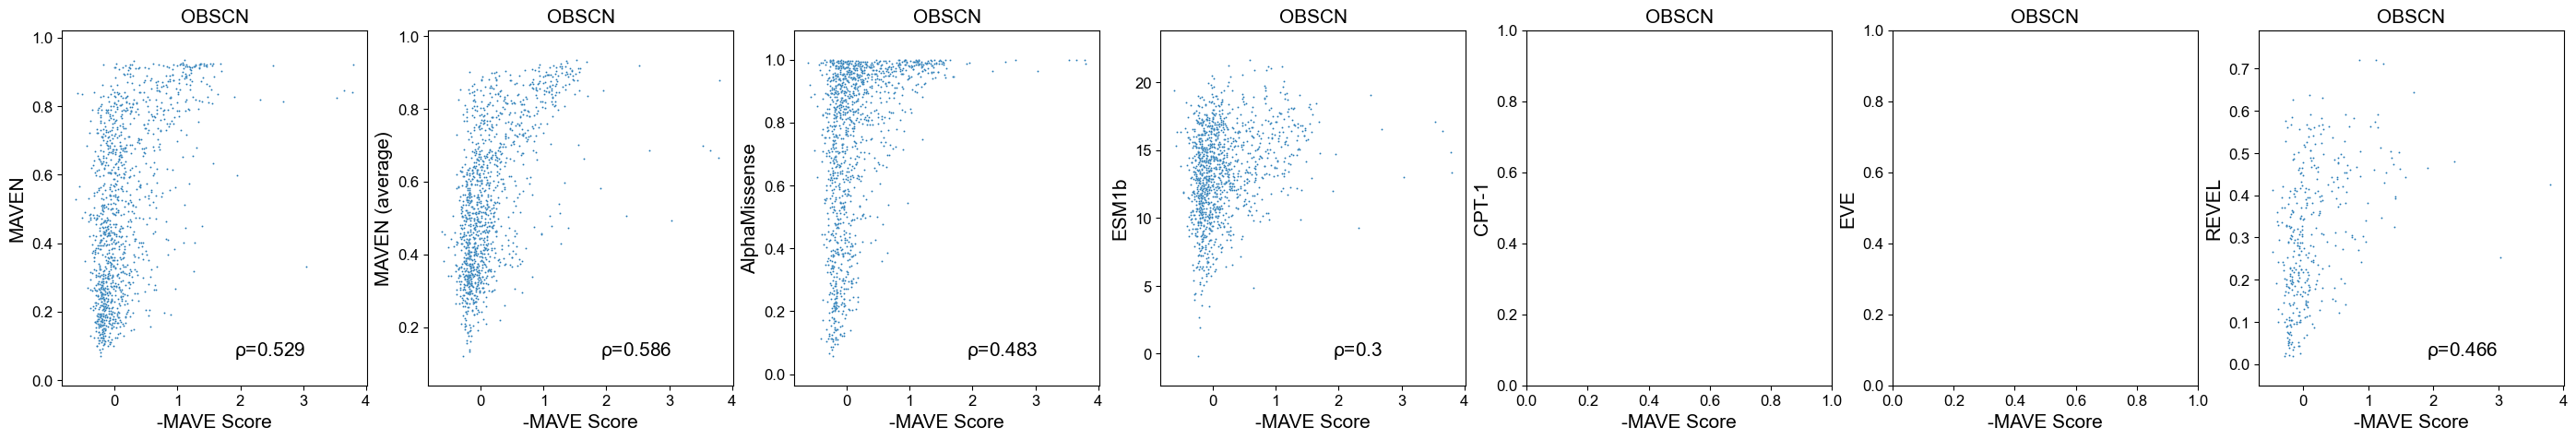

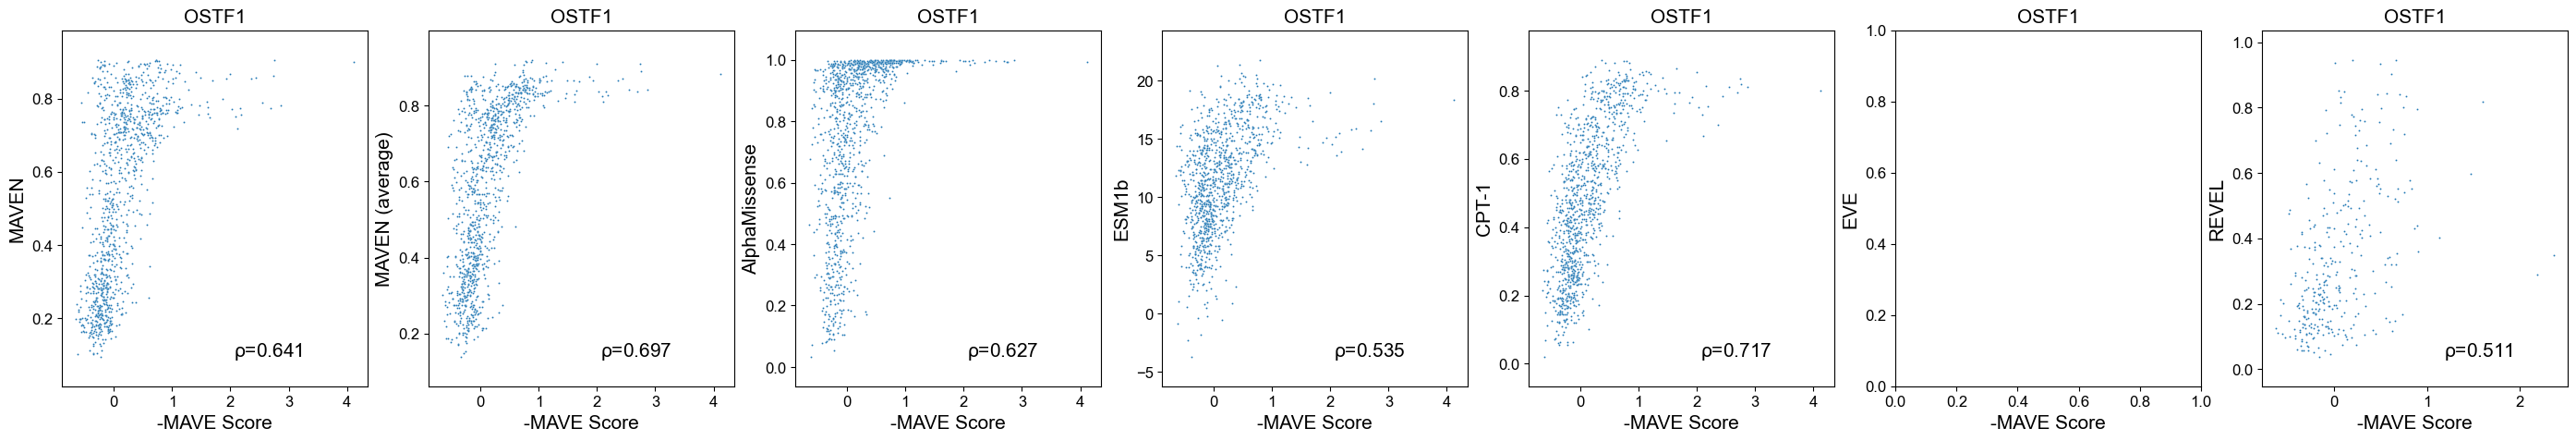

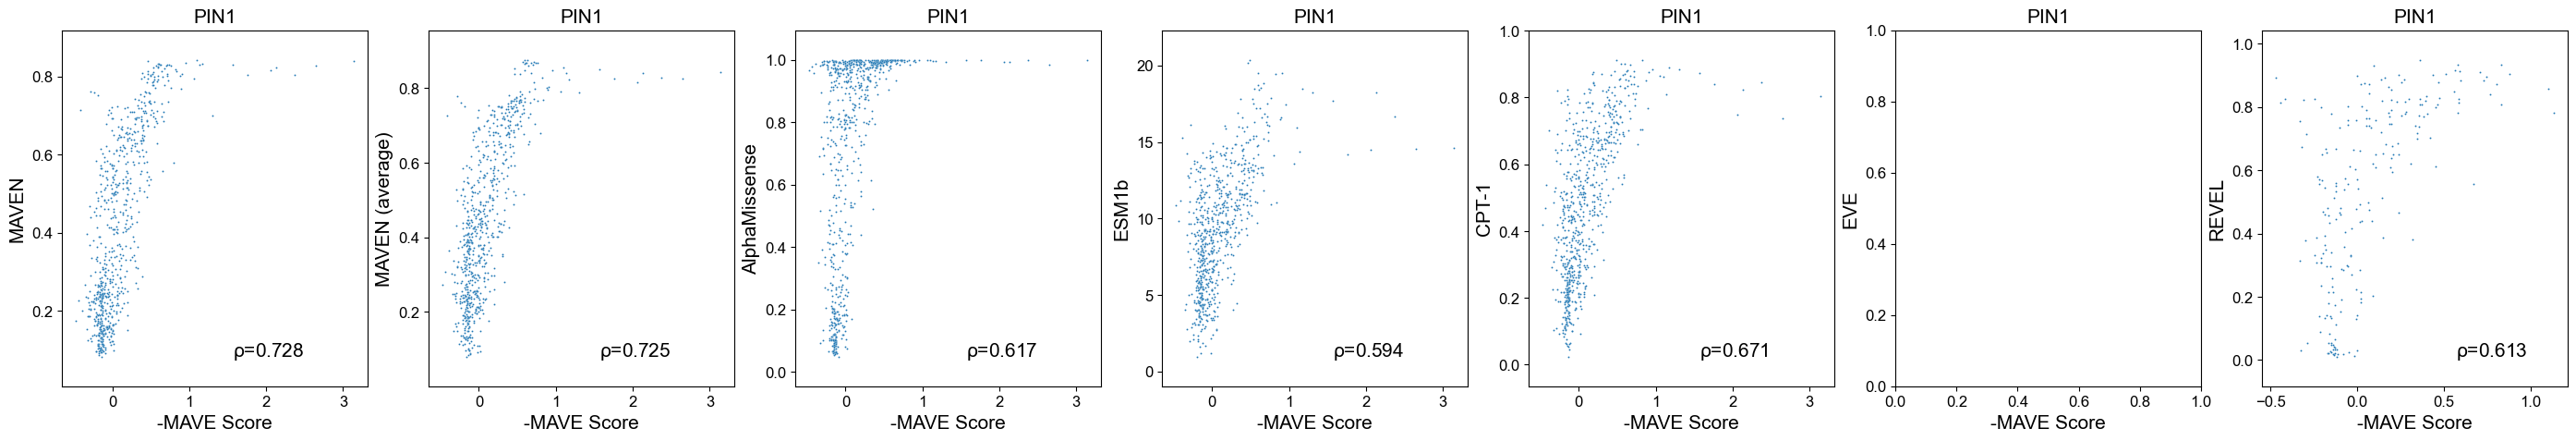

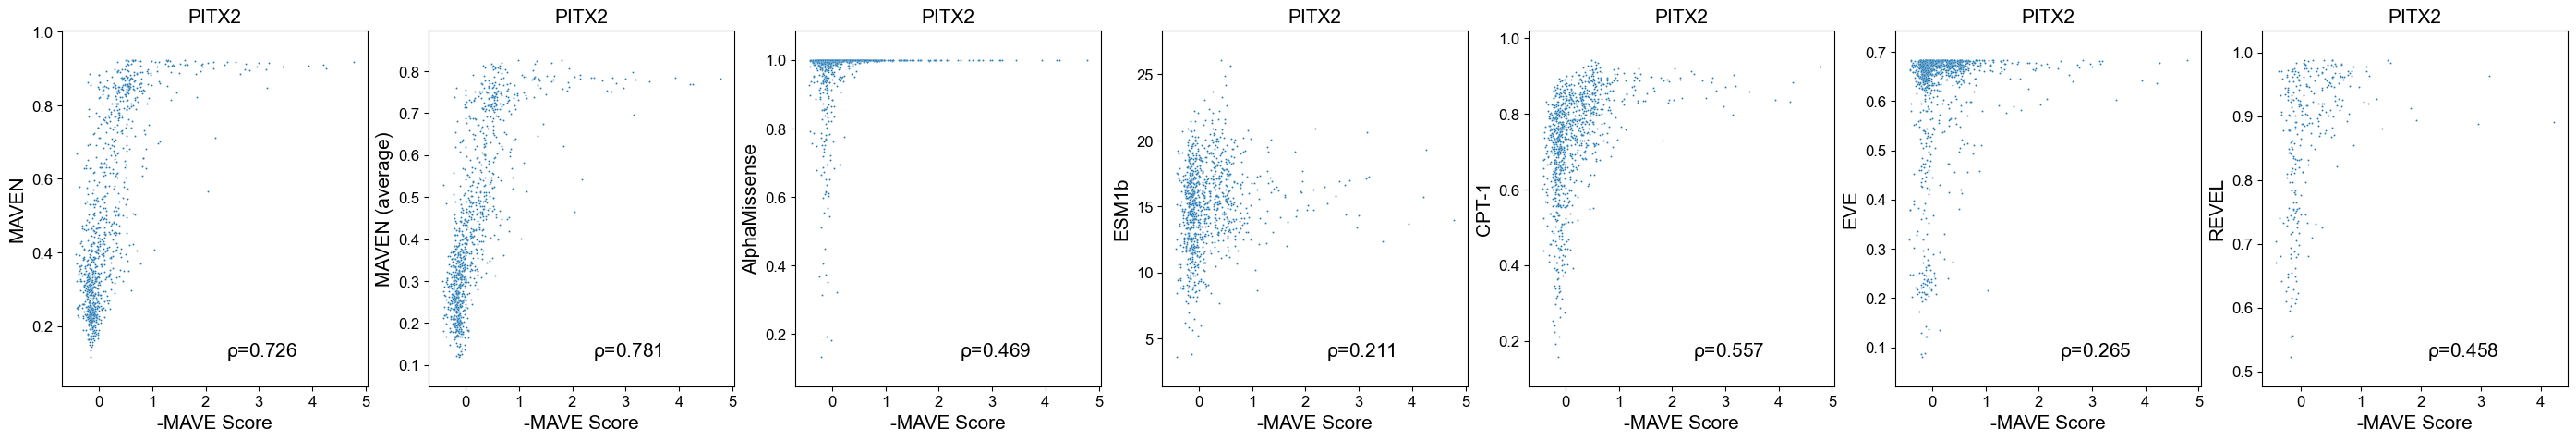

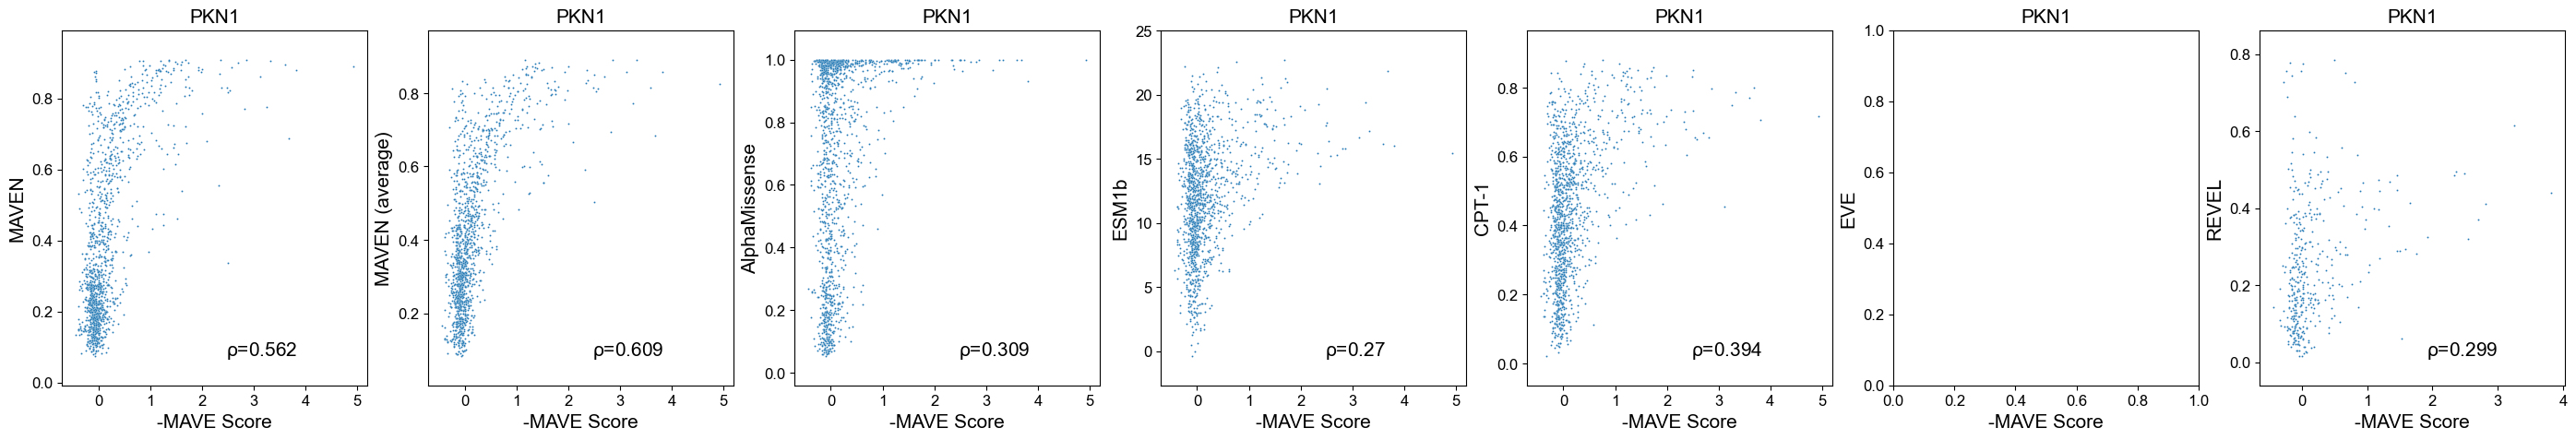

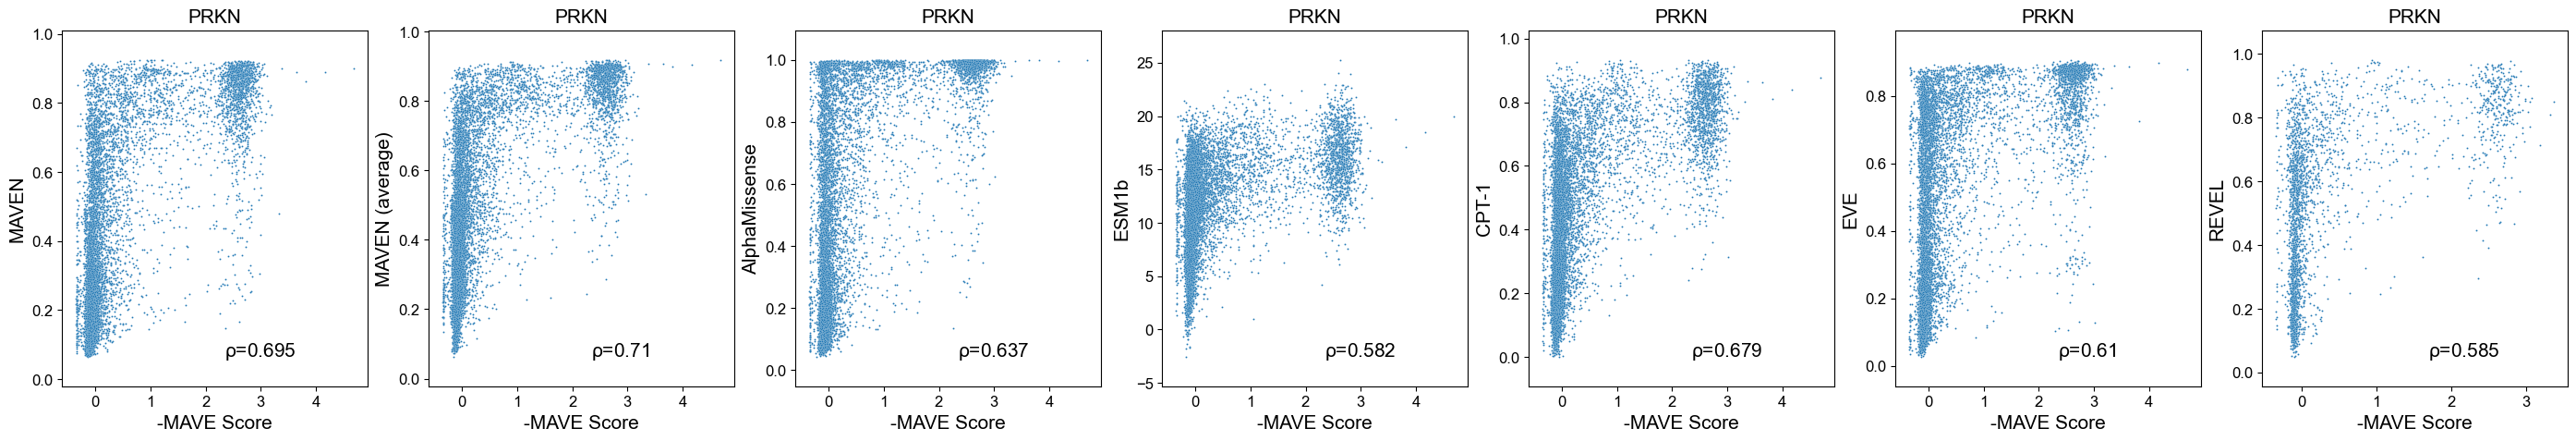

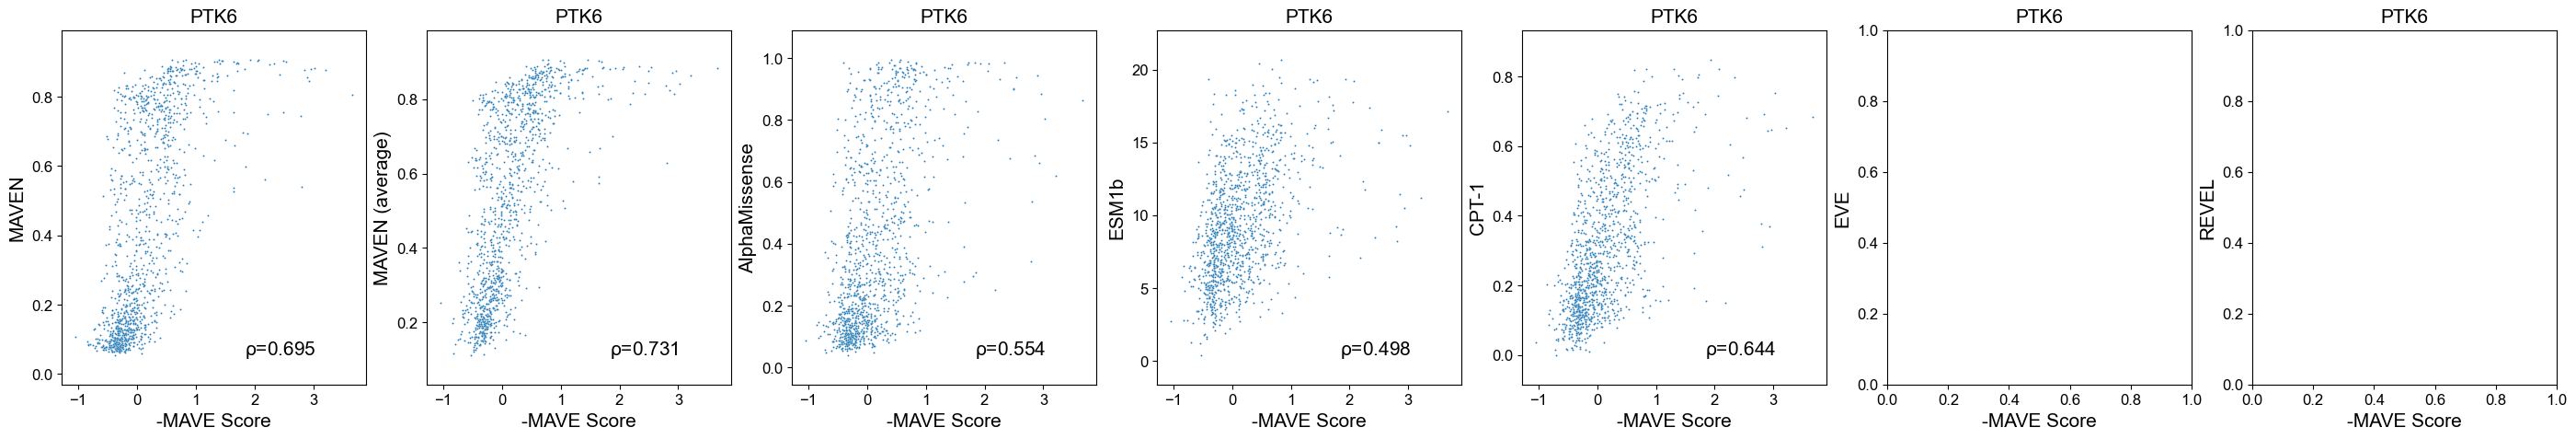

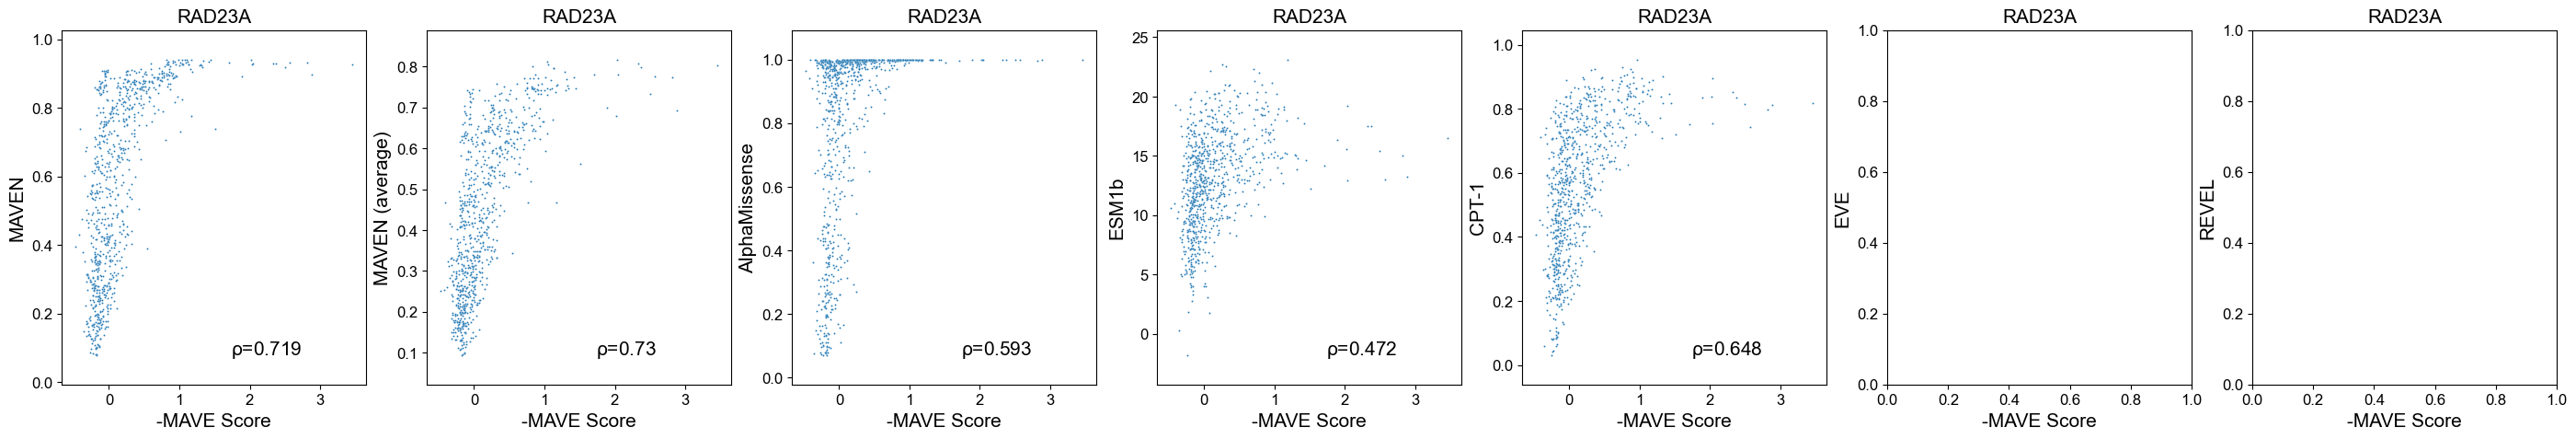

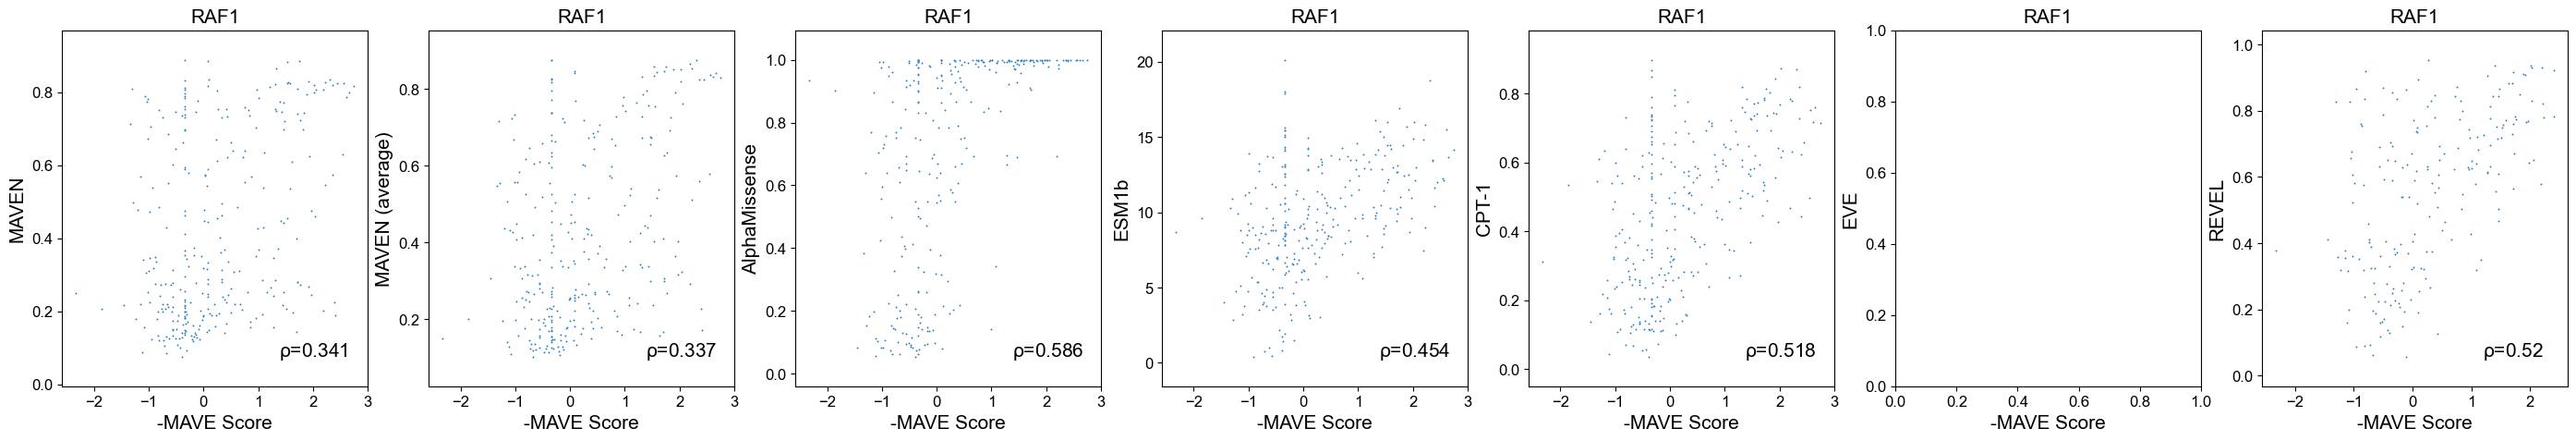

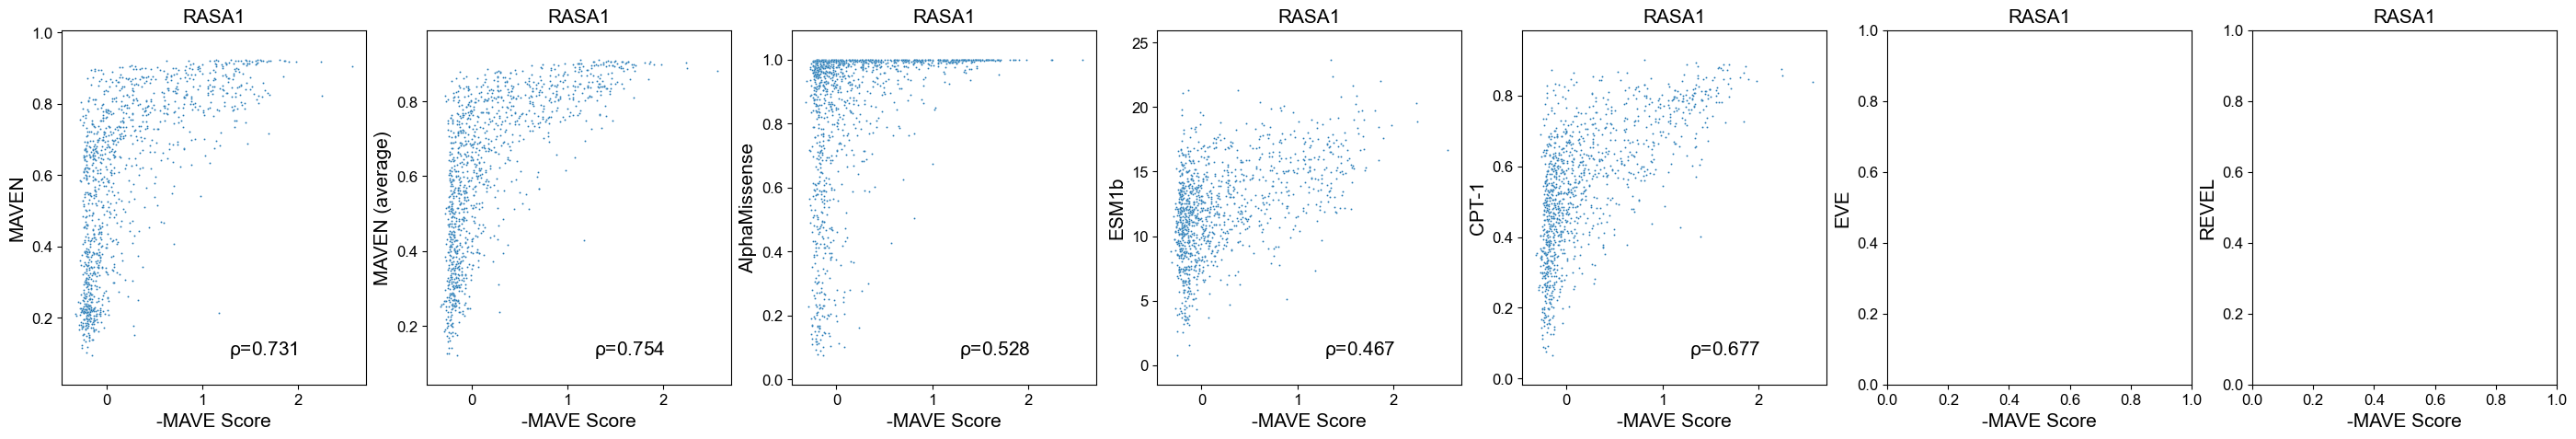

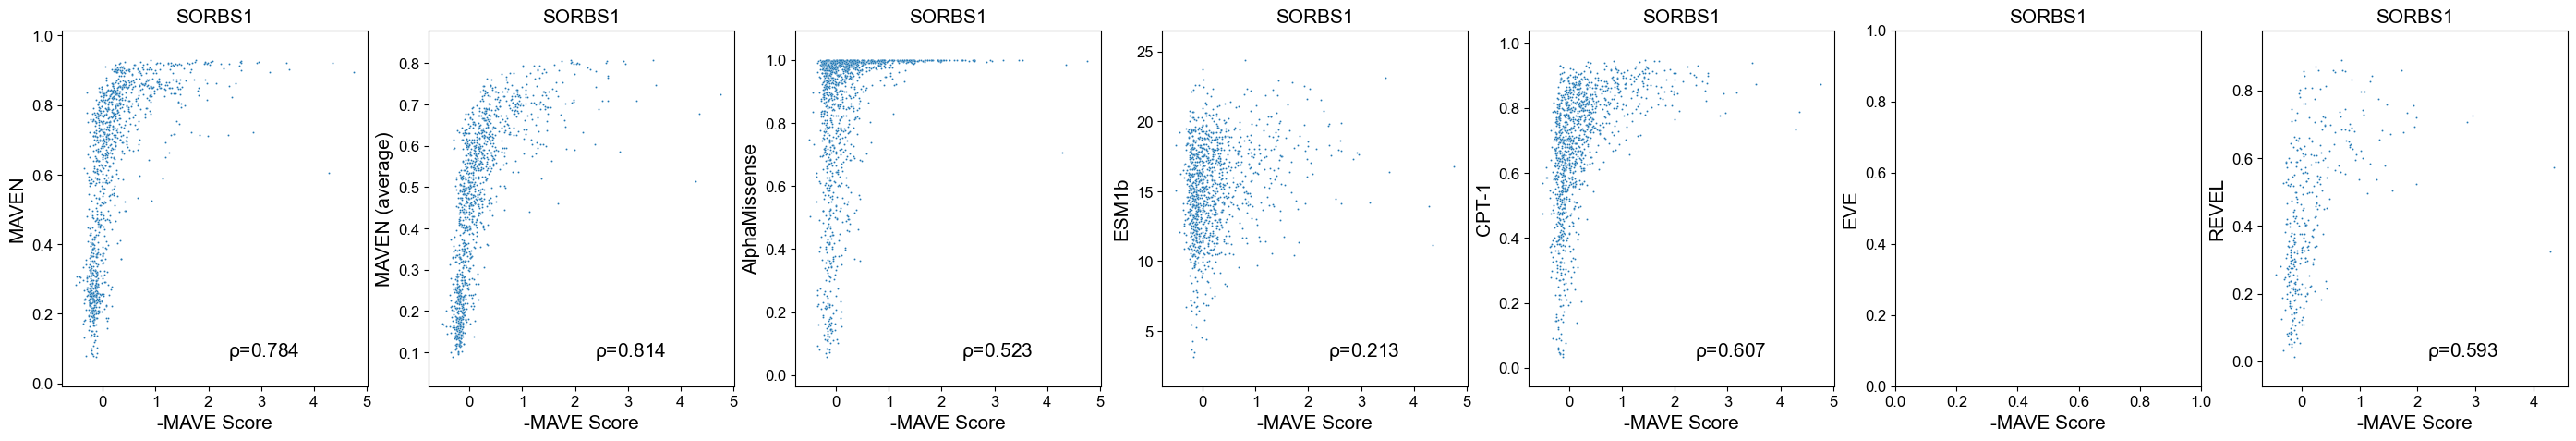

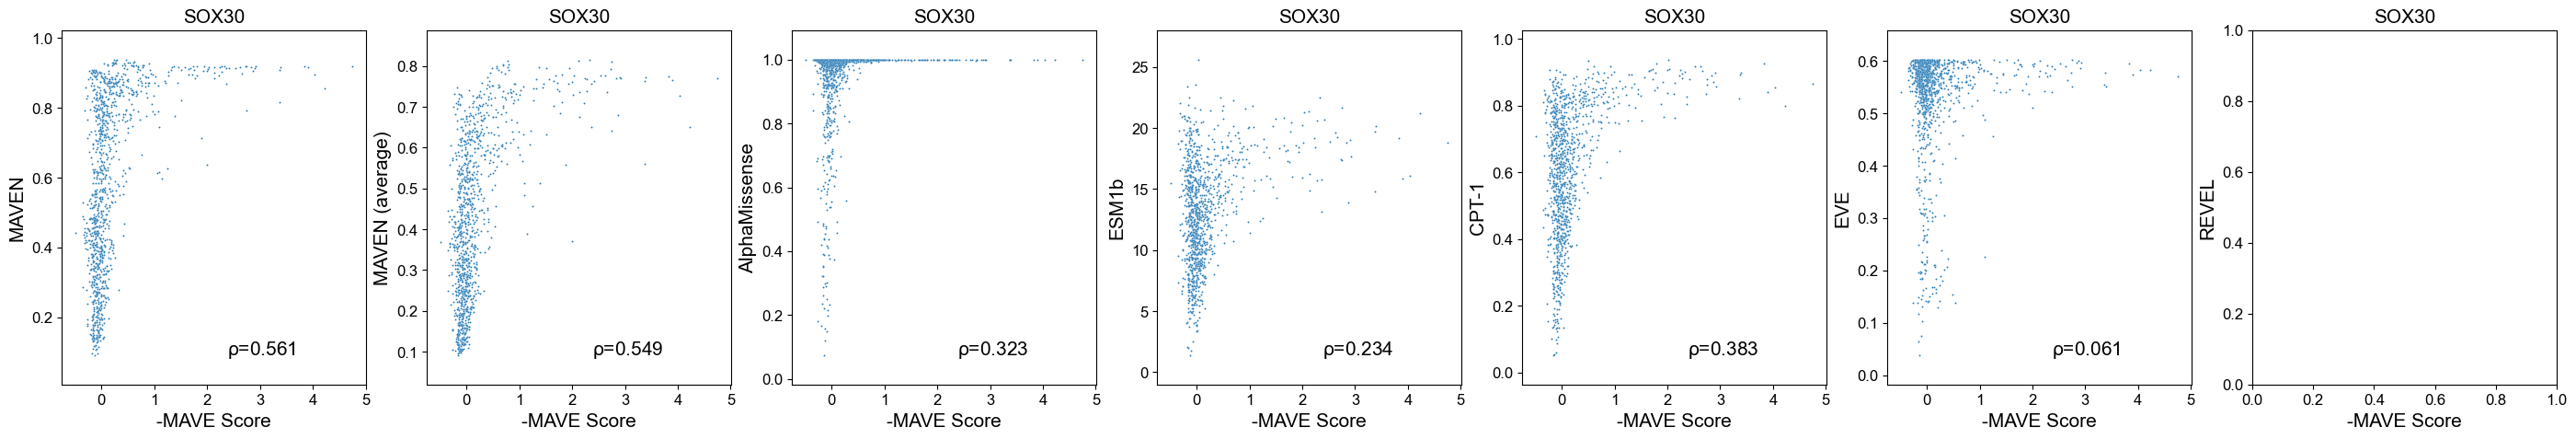

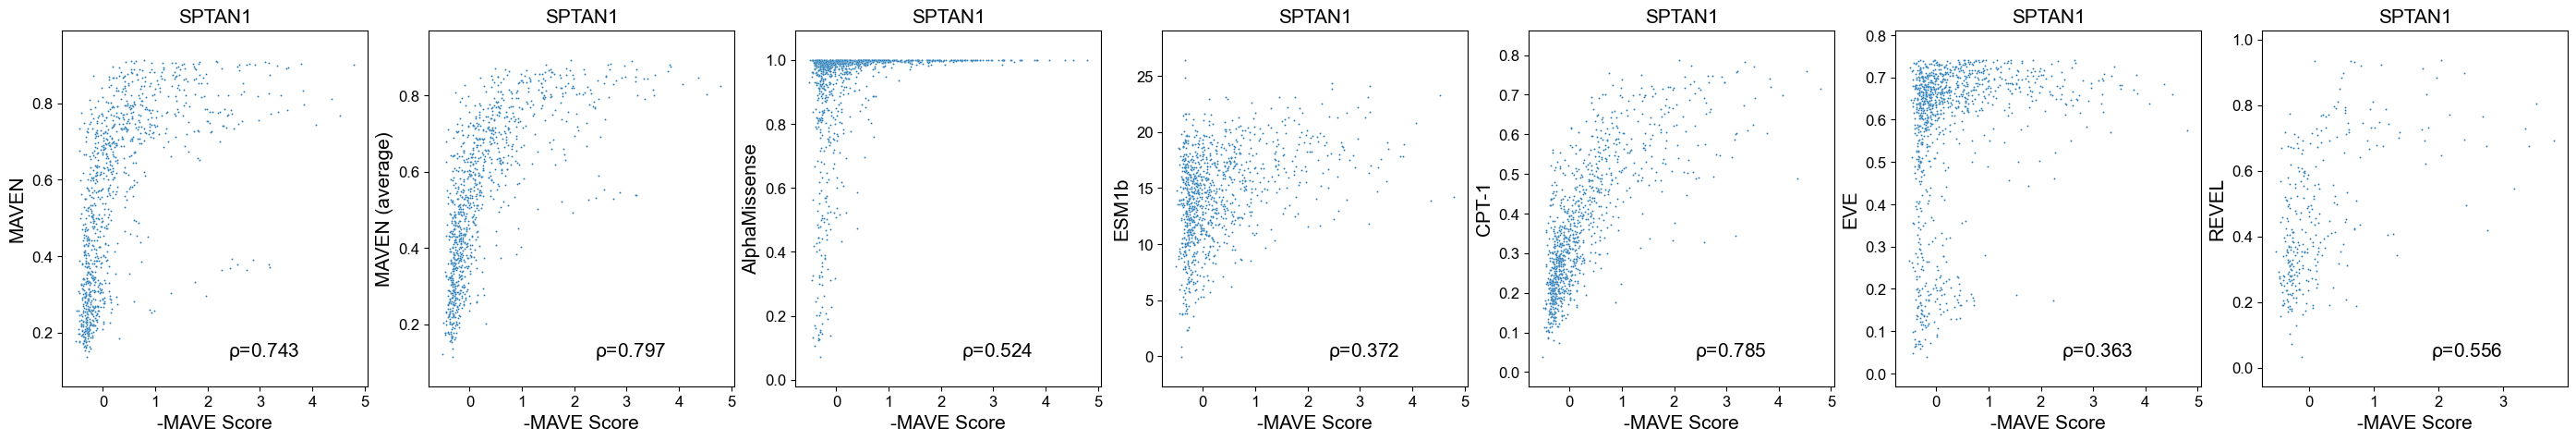

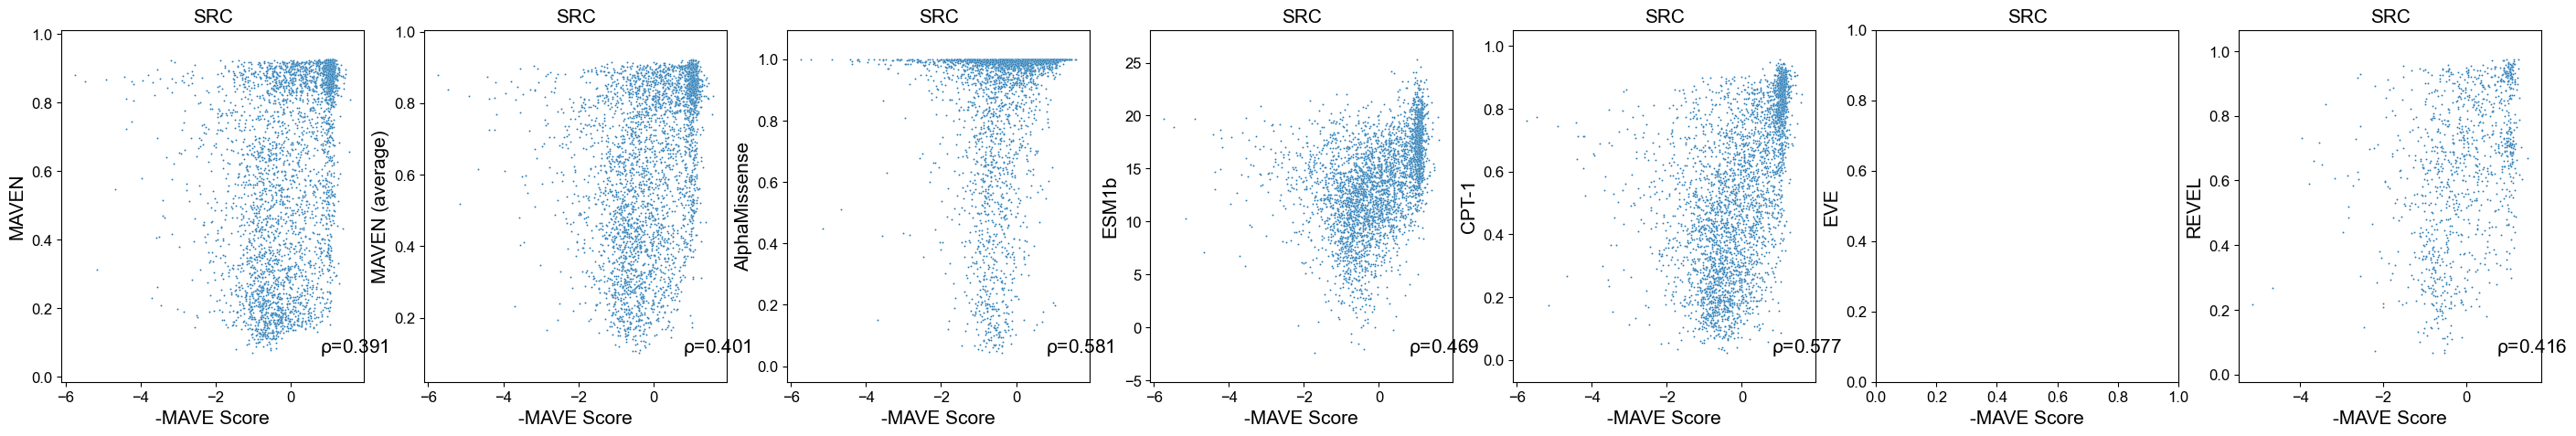

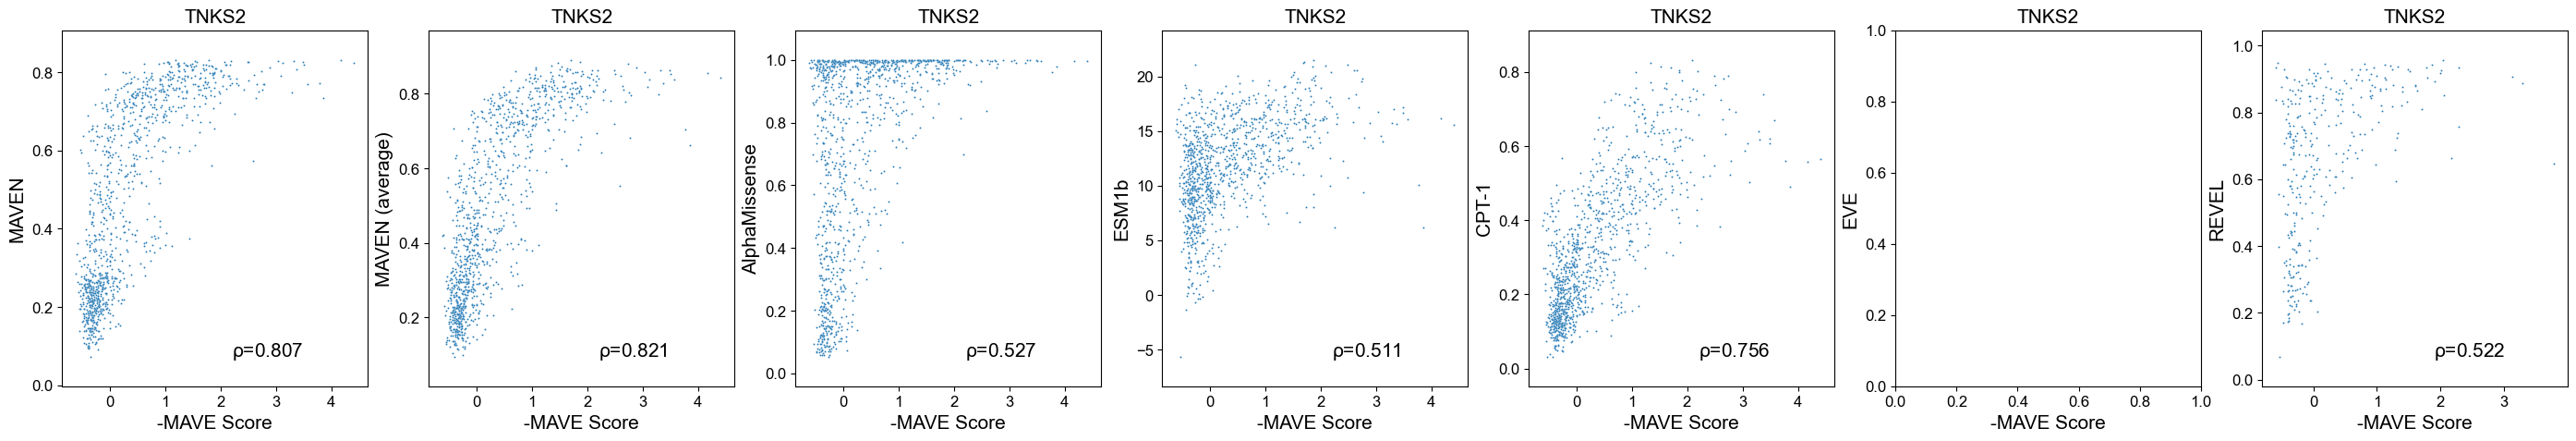

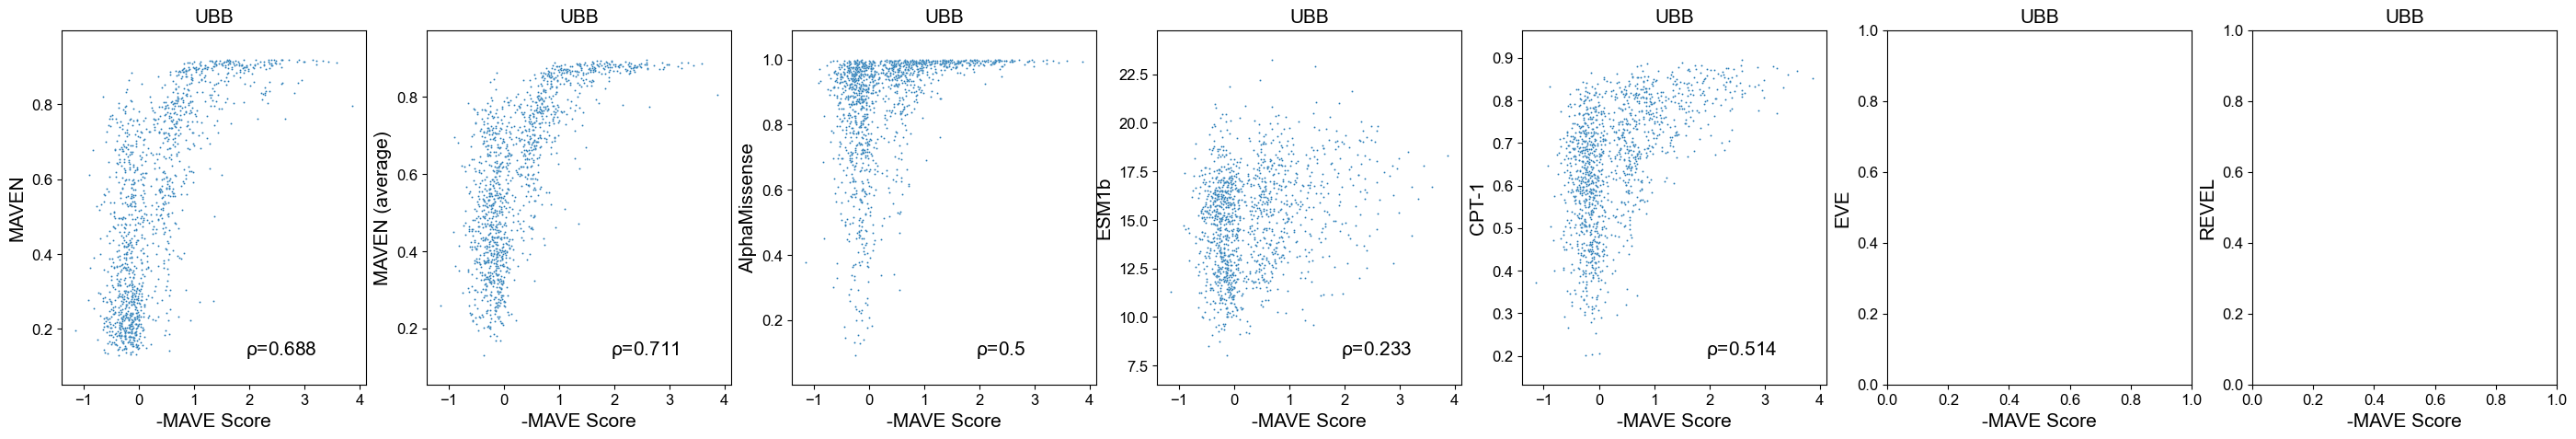

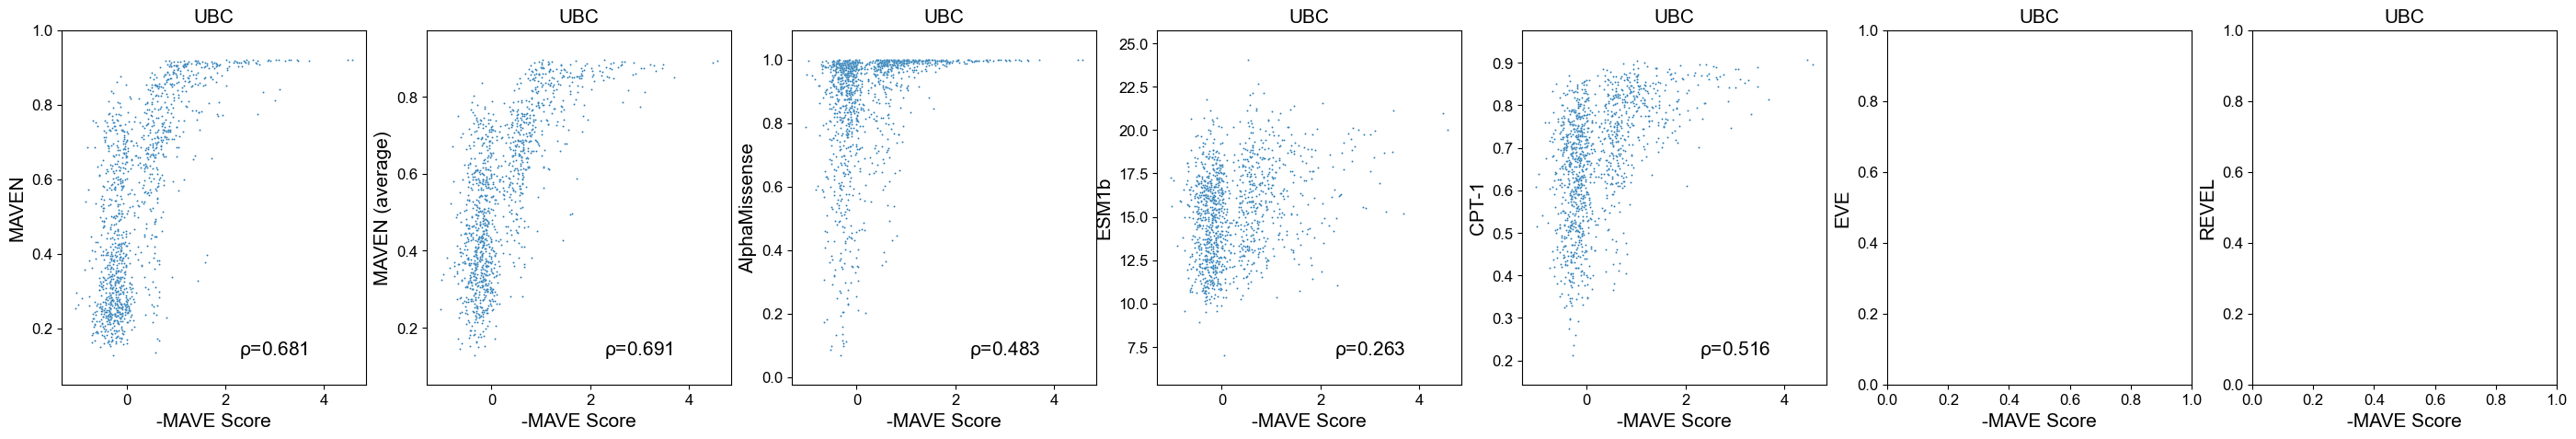

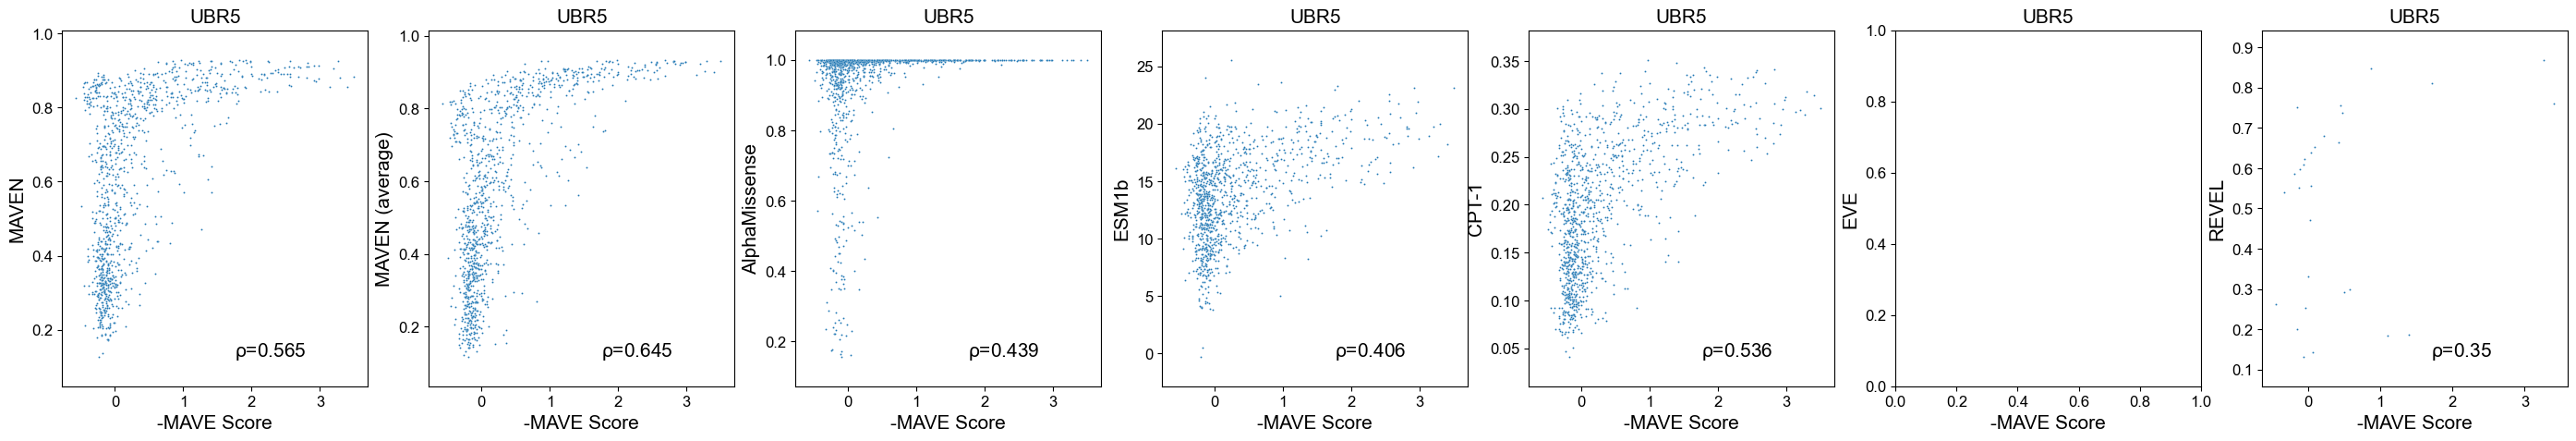

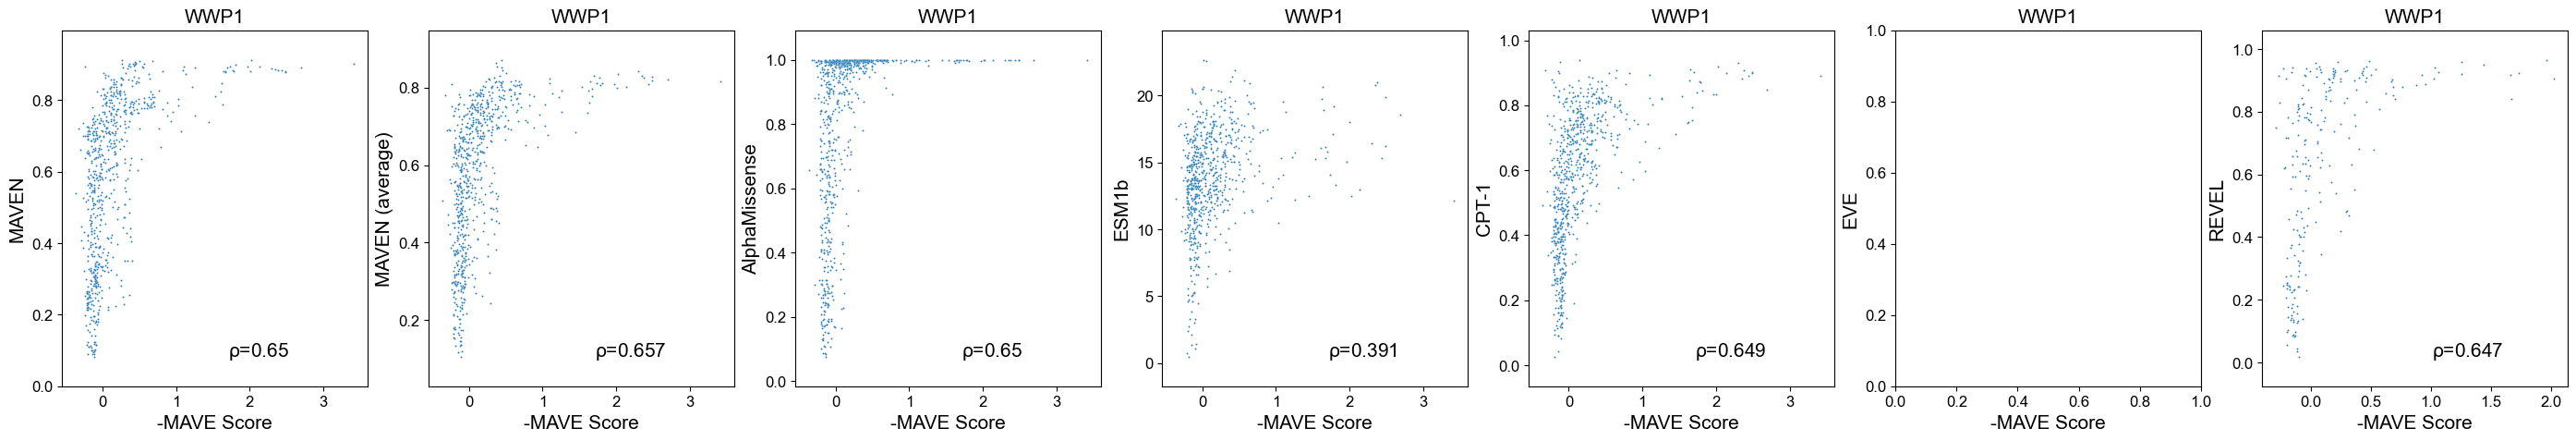

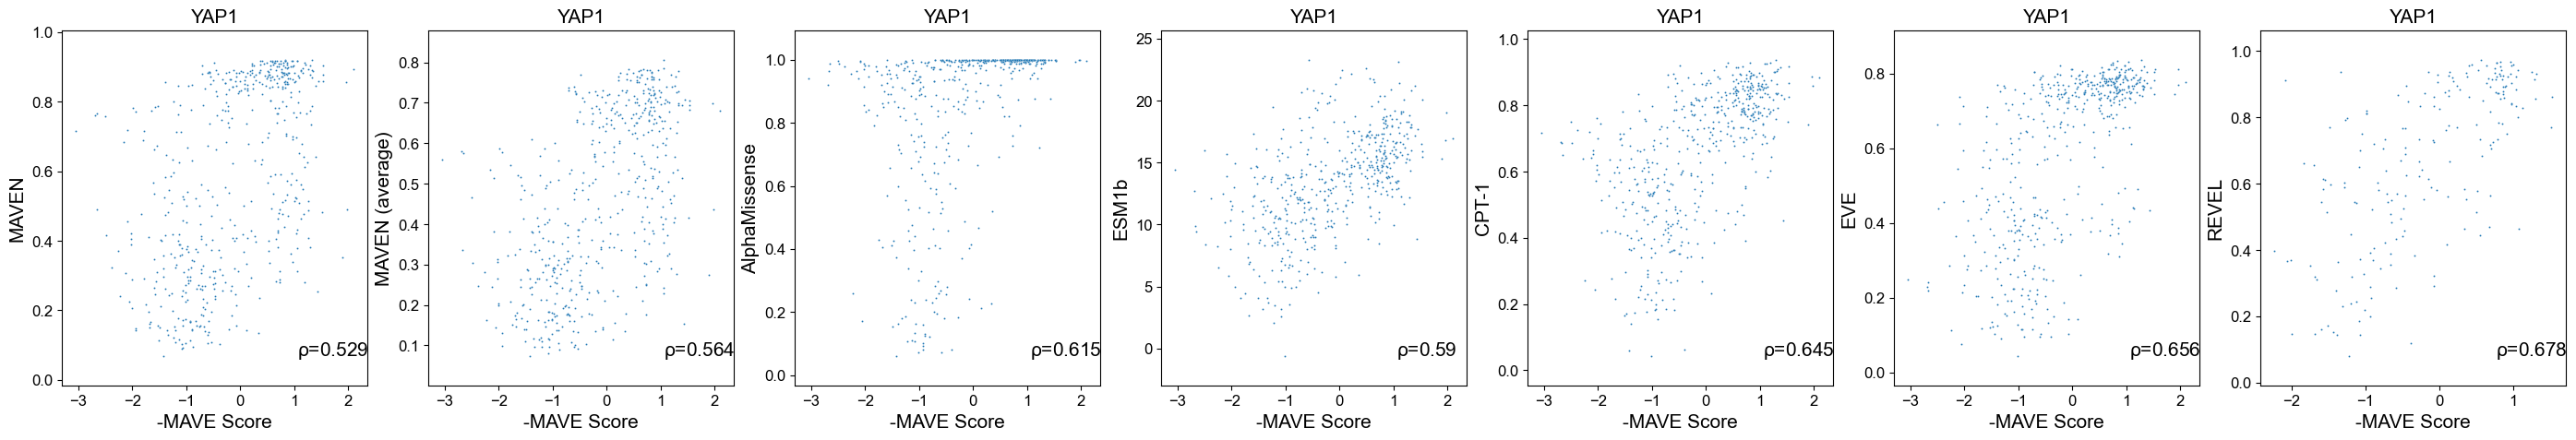

In [26]:
plot_df_raw_score = plot_score_corr(DATA=benchmark_dataset, SCORE='norm_raw_score', COMPARISONS=["MAVEN_score","MAVEN_score_base","am_pathogenicity","ESM1b",'CPT1_score','EVE_score','REVEL'], MAPPING=feature_names, SCORE_TITLE = '-MAVE Score')
plot_df_raw_score['Method'] = plot_df_raw_score['Method'].map(feature_names)

# Plot performance

In [28]:
# Order genes on x axis based on performnace difference between maven and maven (average)
gene_col = []
diff_col = []
for gene in np.unique(plot_df_raw_score['Gene']):
    gene_col.append(gene)
    s = plot_df_raw_score[plot_df_raw_score['Gene']==gene].reset_index(drop=True)
    maven = s[s['Method']== 'MAVEN'].reset_index()['Spearman Correlation Coefficient'][0]
    maven_base = s[s['Method']== 'MAVEN (average)'].reset_index()['Spearman Correlation Coefficient'][0]
    diff = maven_base-maven
    if pd.isnull(diff):
        diff = -1000
    diff_col.append(diff)

gene_order_raw_score = pd.DataFrame({'Gene':gene_col,'Diff':diff_col}).sort_values(by='Diff',ascending=False)
gene_order_raw_score = list(gene_order_raw_score['Gene'])
plot_df_raw_score.Gene = plot_df_raw_score.Gene.astype("category")
plot_df_raw_score.Gene = plot_df_raw_score.Gene.cat.set_categories(gene_order_raw_score)
plot_df_raw_score = plot_df_raw_score.sort_values(["Gene",'Method']).reset_index(drop=True)


marker1 = plot_df_raw_score[plot_df_raw_score['Best Performance']=='Best']
marker2 = plot_df_raw_score[plot_df_raw_score['Best Performance']=='NA']

plot_df_raw_score

,Gene,Method,Spearman Correlation Coefficient,Best Performance,Variant Count
0,DLG4,AlphaMissense,0.481,Best,1235
1,DLG4,CPT-1,NaN,NA,0
2,DLG4,ESM1b,0.392,NA,1235
3,DLG4,EVE,NaN,NA,0
4,DLG4,MAVEN,0.347,NA,1235
...,...,...,...,...,...
345,MAPK1,ESM1b,0.034,NA,6809
346,MAPK1,EVE,NaN,NA,0
347,MAPK1,MAVEN,0.155,NA,6809
348,MAPK1,MAVEN (average),0.117,NA,6809


In [29]:
# Colorbar for MAVE assay type
meta = pd.read_csv('resource_data/MAVEDB_metadata.csv')
meta = meta.replace('UBC9', 'UBC')
acc_2_gene = dict(zip(list(meta['Uniprot_corrected']),list(meta['Approved Symbol'])))
meta = meta[['Approved Symbol','Type']]
meta= meta.set_index(['Approved Symbol'])
meta = meta.loc[gene_order_raw_score].reset_index()
meta.columns = ['Gene','Type']
meta['Type'] = meta['Type'].map({'cDNA Display Proteolysis':3,'VAMP-seq':2,'Function':1})
meta = pd.DataFrame(meta).set_index('Gene')
meta = meta.T
meta

Gene,DLG4,UBR5,BTK,HECTD1,OBSCN,OSTF1,PITX2,SPTAN1,CD2AP,PKN1,...,DUX4,HRAS,PIN1,RAF1,APBB3,CCR5,SOX30,ERBB2,NEDD4,MAPK1
Type,1,3,3,3,3,3,3,3,3,3,...,3,1,3,1,3,1,3,1,3,1


In [30]:
# Step 1: Get descending gene order based on "MAVEN (average)"
avg_scores = plot_df_raw_score[
    plot_df_raw_score['Method'] == 'MAVEN (average)'
].groupby('Gene')['Spearman Correlation Coefficient'].mean()

# Step 2: Sort in descending order
sorted_genes = avg_scores.sort_values(ascending=False).index.tolist()

# Step 3: Set new categorical order
from pandas.api.types import CategoricalDtype
gene_order = CategoricalDtype(categories=sorted_genes, ordered=True)

# Step 4: Apply to all relevant dataframes
plot_df_raw_score['Gene'] = plot_df_raw_score['Gene'].astype(gene_order)
marker1['Gene'] = marker1['Gene'].astype(gene_order)
marker2['Gene'] = marker2['Gene'].astype(gene_order)


/var/folders/7v/1hw0skqj72dczc6xdjymzmyh0000gn/T/ipykernel_88360/3696111284.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marker1['Gene'] = marker1['Gene'].astype(gene_order)
/var/folders/7v/1hw0skqj72dczc6xdjymzmyh0000gn/T/ipykernel_88360/3696111284.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marker2['Gene'] = marker2['Gene'].astype(gene_order)


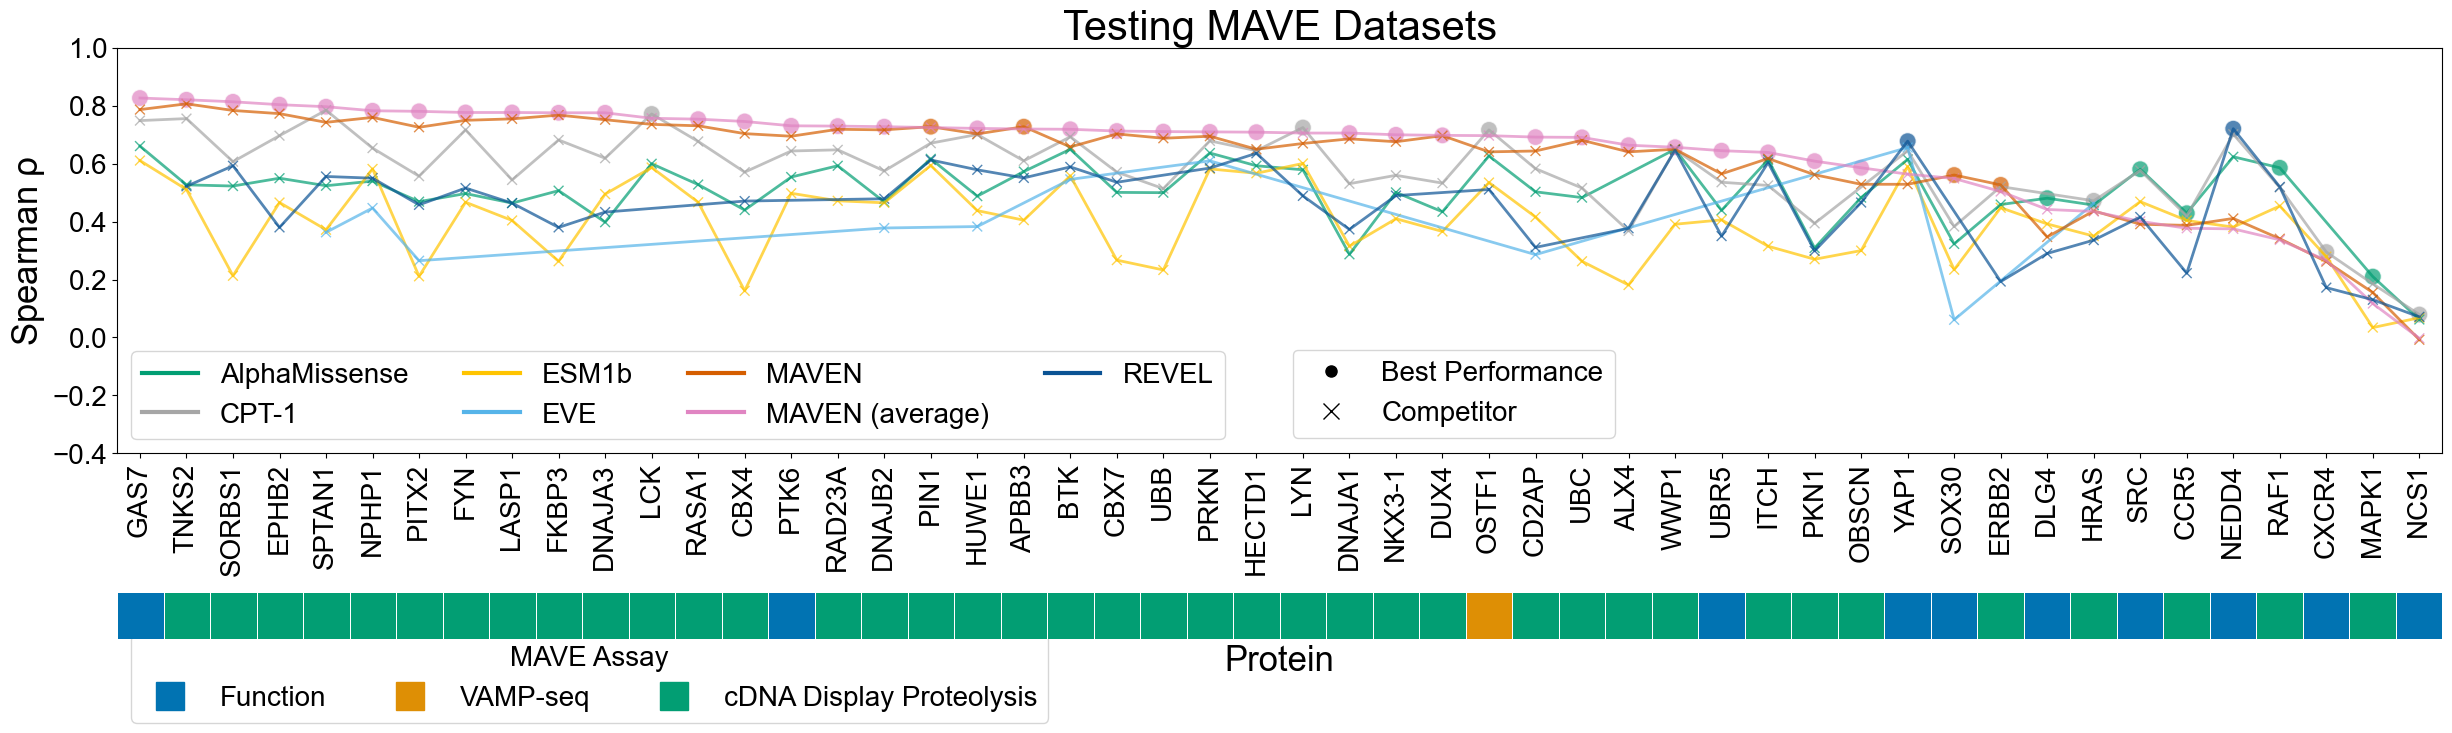

In [31]:
fig,ax = plt.subplots(2, figsize=(30,10))
sns.scatterplot(data=marker1, x='Gene', y='Spearman Correlation Coefficient', hue='Method',marker='o',palette=feature_colors,legend=False,s=150,alpha=0.7,ax=ax[0])
sns.scatterplot(data=marker2, x='Gene', y='Spearman Correlation Coefficient', hue='Method',marker="x",palette=feature_colors,s=50,ec='face',linewidth=1,legend=False,alpha=0.7,ax=ax[0])
sns.lineplot(data=plot_df_raw_score, x='Gene', y='Spearman Correlation Coefficient', hue='Method', lw=2, linestyle='-',palette=feature_colors,alpha=0.7,ax=ax[0])
patch1 = Line2D([], [], color="black", marker='o',linestyle='None',markersize=8)
patch2 = Line2D([], [], color="black", marker="x",linewidth=1,linestyle='None',markersize=12)
ax[0].tick_params('both',labelsize=20)
ax[0].tick_params('x',rotation=90)
legend1 = ax[0].legend(loc=3,fontsize=20,ncol=4)
for leg in legend1.get_lines():
    leg.set_linewidth(3.0)
ax[0].add_artist(legend1)
legend2 = ax[0].legend((patch1,patch2), ('Best Performance', 'Competitor'), bbox_to_anchor=[0.65,0.29],fontsize=20)
ax[0].add_artist(legend2)
ax[0].set_ylabel('Spearman ' + r'$\rho$',fontsize=25)
ax[0].set_xlabel('',fontsize=20)
ax[0].set_title('Testing MAVE Datasets',fontsize=30)
ax[0].set_ylim([-0.4,1])

patch3 = Line2D([], [], color=sns.color_palette("colorblind").as_hex()[0], marker='s',linestyle='None',markersize=20)
patch4 = Line2D([], [], color=sns.color_palette("colorblind").as_hex()[1], marker='s',linestyle='None',markersize=20)
patch5 = Line2D([], [], color=sns.color_palette("colorblind").as_hex()[2], marker='s',linestyle='None',markersize=20)
legend3 = ax[0].legend((patch3,patch4,patch5), ('Function', 'VAMP-seq','cDNA Display Proteolysis'),fontsize=20,ncols=3,title='MAVE Assay',title_fontsize=20 ,loc='lower left',bbox_to_anchor=[0,-0.7]) #bbox_to_anchor=[0,-0.5]

sns.heatmap(meta, cmap=sns.color_palette("colorblind").as_hex()[0:3],cbar=False,yticklabels=False,xticklabels=False,square = True,linewidths=.5,ax=ax[1])
ax[1].set_xlabel('Protein',fontsize=25)
ax[0].margins(x=0.01)
plt.subplots_adjust(wspace=0, hspace=-0.1)

#plt.savefig('maven_'+version+'/figures'+'/percentile_'+str(y_percentile)+'/benchmarks/external_mave/testing_mave_dataset_benchmark.png',bbox_inches='tight',dpi=300)
#plt.savefig('maven_'+version+'/figures'+'/percentile_'+str(y_percentile)+'/benchmarks/external_mave/testing_mave_dataset_benchmark.svg',bbox_inches='tight')

plt.show()

In [32]:
type = pd.read_csv('resource_data/MAVEDB_metadata.csv', index_col=0)[['Approved Symbol', 'Type']]
type = type.replace('UBC9', 'UBC')
plot_df_raw_score_2 = pd.merge(type.set_index('Approved Symbol'), plot_df_raw_score.set_index('Gene'), left_index=True, right_index=True).reset_index()
plot_df_raw_score_2

,Approved Symbol,Type,Method,Spearman Correlation Coefficient,Best Performance,Variant Count
0,ALX4,cDNA Display Proteolysis,AlphaMissense,NaN,NA,0
1,ALX4,cDNA Display Proteolysis,CPT-1,0.368,NA,902
2,ALX4,cDNA Display Proteolysis,ESM1b,0.181,NA,902
3,ALX4,cDNA Display Proteolysis,EVE,NaN,NA,0
4,ALX4,cDNA Display Proteolysis,MAVEN,0.641,NA,902
...,...,...,...,...,...,...
345,YAP1,Function,ESM1b,0.590,NA,513
346,YAP1,Function,EVE,0.656,NA,513
347,YAP1,Function,MAVEN,0.529,NA,513
348,YAP1,Function,MAVEN (average),0.564,NA,513


In [33]:
best_overall = Counter(plot_df_raw_score_2[plot_df_raw_score_2['Best Performance']=='Best']['Method'])
best_overall

Counter({'MAVEN (average)': 33,
         'CPT-1': 6,
         'AlphaMissense': 5,
         'MAVEN': 4,
         'REVEL': 2})

In [34]:
best_folding = Counter(plot_df_raw_score_2[(plot_df_raw_score_2['Best Performance']=='Best')&(plot_df_raw_score_2['Type']=='cDNA Display Proteolysis')]['Method'])
best_folding 

Counter({'MAVEN (average)': 32, 'MAVEN': 3, 'CPT-1': 3, 'REVEL': 1})

In [35]:
best_vamp = Counter(plot_df_raw_score_2[(plot_df_raw_score_2['Best Performance']=='Best')&(plot_df_raw_score_2['Type']=='VAMP-seq')]['Method'])
best_vamp

Counter({'MAVEN (average)': 1})

In [36]:
best_function = Counter(plot_df_raw_score_2[(plot_df_raw_score_2['Best Performance']=='Best')&(plot_df_raw_score_2['Type']=='Function')]['Method'])
best_function

Counter({'AlphaMissense': 5, 'CPT-1': 3, 'MAVEN': 1, 'REVEL': 1})